# 🏦 ZEDCREST CAPITAL — Data Analyst Training Programme
## Algorithm-Based ATM Card Fraud Detection
### Using Machine Learning on the Same Dataset

---

> **Trainer:** Kajola Gbenga Adewale | Prodigy Training Hub  
> **Dataset:** `atm_transactions.csv` — 2,229 real-style Nigerian bank transactions  
> **Approach:** Machine Learning (Algorithm-Based) — upgrading from the Rule-Based system  

---

## 📋 What We Are Doing Today

In the **Rule-Based** notebook, we wrote explicit rules:
> *"If amount > 3× typical max → flag it"*

In this **Algorithm-Based** notebook, we let the **machine learn the patterns from the data itself**. No manually written rules. The algorithm discovers which features distinguish fraud from normal transactions on its own.

---

## 🧠 Algorithms We Will Use

| # | Algorithm | Type | Why |
|---|-----------|------|-----|
| 1 | **Logistic Regression** | Supervised | Fast baseline; shows feature importance |
| 2 | **Decision Tree** | Supervised | Visual, explainable; mirrors rule-based logic |
| 3 | **Random Forest** | Supervised (Ensemble) | Best overall performance; handles class imbalance |
| 4 | **XGBoost** (Gradient Boosting) | Supervised (Ensemble) | Industry standard for fraud detection |
| 5 | **Isolation Forest** | Unsupervised | Detects anomalies WITHOUT needing fraud labels |
| 6 | **Model Comparison** | — | Side-by-side evaluation of all models |

---

## 🗺️ Session Roadmap

| Section | Topic |
|---------|-------|
| **0** | Load & Explore the Dataset |
| **1** | Feature Engineering — creating ML-ready features |
| **2** | Train/Test Split & Class Imbalance Handling |
| **3** | Logistic Regression |
| **4** | Decision Tree |
| **5** | Random Forest |
| **6** | XGBoost (Gradient Boosting) |
| **7** | Isolation Forest (Unsupervised) |
| **8** | Model Comparison & Champion Selection |
| **9** | Feature Importance — what matters most |
| **10** | Capstone — Full Production Pipeline |


---
## 📂 Section 0 — Load and Explore the Dataset

We start with the same `atm_transactions.csv` used in the Rule-Based notebook.  
This time we use **Pandas** (faster and more powerful than the built-in `csv` module)  
and we explore the data more deeply to prepare it for machine learning.


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0 — IMPORTS
#
# Everything we need for the entire notebook is imported here at the top.
# This is professional practice — one clean import block, not scattered imports.
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd                          # data loading and manipulation
import numpy as np                           # numerical operations
import matplotlib.pyplot as plt              # plotting
import matplotlib.patches as mpatches        # legend patches for plots
import seaborn as sns                        # statistical visualisations
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn: the core ML library ────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    precision_score, recall_score, f1_score, accuracy_score,
    ConfusionMatrixDisplay
)

# ── XGBoost ───────────────────────────────────────────────────────────────────
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost imported successfully")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost not installed — run: pip install xgboost")
    print("   Gradient Boosting from sklearn will be used as substitute.")
    from sklearn.ensemble import GradientBoostingClassifier

# ── SMOTE: for handling class imbalance ──────────────────────────────────────
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print("✅ SMOTE (imbalanced-learn) imported successfully")
except ImportError:
    SMOTE_AVAILABLE = False
    print("⚠️  imbalanced-learn not installed — run: pip install imbalanced-learn")

# ── Plot styling ──────────────────────────────────────────────────────────────
plt.style.use('dark_background')
PALETTE = {
    'fraud':  '#EF4444',   # red   → fraud
    'normal': '#0EA5E9',   # blue  → normal
    'gold':   '#F59E0B',   # gold  → accent
    'green':  '#22C55E',   # green → good metrics
    'purple': '#8B5CF6',   # purple → secondary
}

print()
print("=" * 55)
print("  ALL IMPORTS SUCCESSFUL — READY FOR ML")
print("=" * 55)


✅ XGBoost imported successfully
✅ SMOTE (imbalanced-learn) imported successfully

  ALL IMPORTS SUCCESSFUL — READY FOR ML


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0.1 — LOAD THE DATASET
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv('atm_transactions.csv')

# Convert numeric columns that pandas may read as strings
numeric_cols = ['amount_naira', 'balance_before', 'balance_after',
                'typical_max_amount', 'daily_limit', 'daily_total_so_far']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Create binary target variable: 1 = fraud, 0 = normal
# This is the column our models will learn to predict
df['is_fraud'] = (df['is_fraud_flag'] == 'SUSPICIOUS').astype(int)

print("=" * 55)
print("  DATASET LOADED SUCCESSFULLY")
print("=" * 55)
print(f"  Total rows       : {len(df):,}")
print(f"  Total columns    : {df.shape[1]}")
print(f"  Fraud cases      : {df['is_fraud'].sum():,}  ({df['is_fraud'].mean()*100:.1f}%)")
print(f"  Normal cases     : {(1-df['is_fraud']).sum():,}  ({(1-df['is_fraud']).mean()*100:.1f}%)")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print("=" * 55)
print()
df.head(3)


  DATASET LOADED SUCCESSFULLY
  Total rows       : 2,229
  Total columns    : 24
  Fraud cases      : 270  (12.1%)
  Normal cases     : 1,959  (87.9%)
  Missing values   : 1959



,transaction_id,date,time,day_of_week,customer_id,customer_name,account_number,card_last4,card_type,bank,...,atm_location,home_state,customer_profile,typical_max_amount,daily_limit,daily_total_so_far,transaction_status,is_fraud_flag,fraud_reason,is_fraud
0,TXN000708,2026-01-01,01:16:15,Thursday,CUST0024,Ola Babatunde,4288813383,7897,Verve,Zenith Bank,...,"ATM_LG_004 - Surulere, Lagos",Enugu,medium_spender,50000,150000,4023.12,Successful,NORMAL,NaN,0
1,TXN000025,2026-01-01,01:27:24,Thursday,CUST0002,Efua Babatunde,9356327295,2359,Visa Credit,Zenith Bank,...,"ATM_LG_001 - Ikeja Branch, Lagos",Kaduna,medium_spender,50000,150000,0.00,Declined,NORMAL,NaN,0
2,TXN000212,2026-01-01,03:23:43,Thursday,CUST0008,Tobi Ibrahim,1205673434,2732,Mastercard Debit,First Bank,...,"ATM_LG_004 - Surulere, Lagos",Ibadan,low_spender,10000,50000,3095.63,Successful,NORMAL,NaN,0


CLASS IMBALANCE ANALYSIS
---------------------------------------------
  Normal transactions : 1,959  (87.9%)
  Fraud  transactions : 270   (12.1%)
  Imbalance ratio     : 7.3:1  (for every 1 fraud, 7 normal)

⚠️  WARNING: Imbalanced dataset detected!
   A naive model that predicts 'normal' for EVERYTHING achieves:
   Accuracy = 87.9% — but Recall = 0%  (misses ALL fraud)

   Solutions we will apply:
   1. class_weight='balanced' — penalise misclassifying fraud more
   2. SMOTE — Synthetic Minority Over-Sampling Technique
   3. Evaluation using Recall & F1, NOT just accuracy



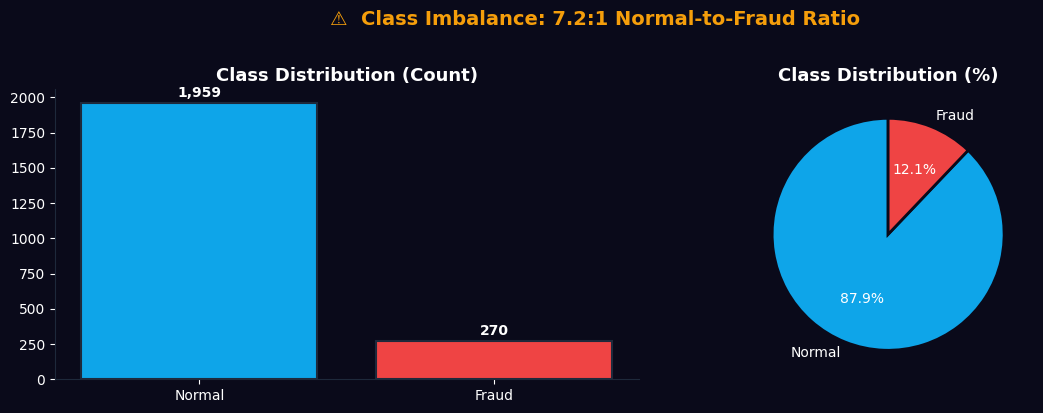

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0.2 — CLASS IMBALANCE ANALYSIS
#
# Class imbalance = the target variable is unevenly distributed.
# In fraud detection: 87.9% normal vs 12.1% fraud.
# If we ignore this, ML models will cheat by predicting "normal" for everything
# and still get 87.9% accuracy — but they will miss ALL fraud.
# This is the single biggest challenge in fraud ML.
# ─────────────────────────────────────────────────────────────────────────────

normal_count = (df['is_fraud'] == 0).sum()
fraud_count  = (df['is_fraud'] == 1).sum()
ratio        = normal_count / fraud_count

print("CLASS IMBALANCE ANALYSIS")
print("-" * 45)
print(f"  Normal transactions : {normal_count:,}  ({normal_count/len(df)*100:.1f}%)")
print(f"  Fraud  transactions : {fraud_count:,}   ({fraud_count/len(df)*100:.1f}%)")
print(f"  Imbalance ratio     : {ratio:.1f}:1  (for every 1 fraud, {ratio:.0f} normal)")
print()
print("⚠️  WARNING: Imbalanced dataset detected!")
print("   A naive model that predicts 'normal' for EVERYTHING achieves:")
print(f"   Accuracy = {normal_count/len(df)*100:.1f}% — but Recall = 0%  (misses ALL fraud)")
print()
print("   Solutions we will apply:")
print("   1. class_weight='balanced' — penalise misclassifying fraud more")
print("   2. SMOTE — Synthetic Minority Over-Sampling Technique")
print("   3. Evaluation using Recall & F1, NOT just accuracy")
print()

# Visualise class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0A0A1A')

# Bar chart
counts = [normal_count, fraud_count]
labels = ['Normal', 'Fraud']
colors = [PALETTE['normal'], PALETTE['fraud']]
bars = axes[0].bar(labels, counts, color=colors, edgecolor='#1E293B', linewidth=1.5)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'{count:,}', ha='center', va='bottom', color='white', fontweight='bold')
axes[0].set_title('Class Distribution (Count)', color='white', fontsize=13, fontweight='bold')
axes[0].set_facecolor('#0A0A1A')
axes[0].tick_params(colors='white')
axes[0].spines['bottom'].set_color('#1E293B')
axes[0].spines['left'].set_color('#1E293B')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': '#0A0A1A', 'linewidth': 2}
)
for text in texts + autotexts:
    text.set_color('white')
axes[1].set_title('Class Distribution (%)', color='white', fontsize=13, fontweight='bold')
axes[1].set_facecolor('#0A0A1A')

plt.suptitle('⚠️  Class Imbalance: 7.2:1 Normal-to-Fraud Ratio',
             color=PALETTE['gold'], fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## ⚙️ Section 1 — Feature Engineering

**Feature engineering** is the process of converting raw data into numerical inputs that a machine learning algorithm can understand.

ML algorithms only work with **numbers**. Our dataset has strings, categories, and datetime-derived fields. We must transform everything.

This step is the most important in the entire ML pipeline — **garbage in, garbage out**.

### What We Will Create

| Feature | Source | Why It Matters |
|---------|--------|----------------|
| `amount_ratio` | amount / typical_max | How many times over normal is this transaction? |
| `hour` | extracted from time | Night-time transactions are suspicious |
| `is_midnight_to_4am` | hour 0–4 | Binary flag for the high-risk window |
| `daily_limit_usage_pct` | daily_total / daily_limit | How much of daily limit has been used? |
| `balance_drain_pct` | (before-after)/before | What % of balance was spent? |
| `is_large_cash` | ATM Withdrawal + high amount | Cash-only high-value transactions |
| Encoded categoricals | bank, card_type, etc. | Convert strings to numbers |


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — FEATURE ENGINEERING
# Converting raw data into ML-ready numerical features
# ─────────────────────────────────────────────────────────────────────────────

df_ml = df.copy()   # always work on a copy — never modify the original

# ── FEATURE 1: Amount ratio ────────────────────────────────────────────────
# How many times over the customer's normal maximum is this transaction?
# A ratio of 8.7 means the transaction is 8.7× their normal max — very suspicious.
# We clip the denominator at 1 to avoid division by zero.
df_ml['amount_ratio'] = df_ml['amount_naira'] / df_ml['typical_max_amount'].clip(lower=1)

# ── FEATURE 2: Extract hour from time string ───────────────────────────────
# time column is "02:34:18" — we need the integer 2
# int(time_str[:2]) extracts the first two characters and converts to int
df_ml['hour'] = df_ml['time'].apply(lambda t: int(str(t)[:2]))

# ── FEATURE 3: High-risk hour binary flag ──────────────────────────────────
# Midnight to 4am is the peak fraud window — create a dedicated binary feature
# astype(int) converts True → 1, False → 0
df_ml['is_midnight_to_4am'] = ((df_ml['hour'] >= 0) & (df_ml['hour'] <= 4)).astype(int)

# ── FEATURE 4: Daily limit usage percentage ────────────────────────────────
# What percentage of the daily limit has already been used?
# 120% means the daily limit has been exceeded — a strong fraud signal
df_ml['daily_limit_usage_pct'] = (
    df_ml['daily_total_so_far'] / df_ml['daily_limit'].clip(lower=1) * 100
).clip(upper=200)   # cap at 200% to handle extreme outliers

# ── FEATURE 5: Balance drain percentage ────────────────────────────────────
# What fraction of the account balance was spent in this one transaction?
# 95% drain = nearly the whole account was taken — a draining attack signal
df_ml['balance_drain_pct'] = (
    (df_ml['balance_before'] - df_ml['balance_after'].clip(lower=0))
    / df_ml['balance_before'].clip(lower=1) * 100
).clip(0, 100)

# ── FEATURE 6: Large cash withdrawal flag ──────────────────────────────────
# ATM Withdrawal AND amount above 2× typical max is a specific pattern
df_ml['is_large_cash'] = (
    (df_ml['transaction_type'] == 'ATM Withdrawal') &
    (df_ml['amount_naira'] > df_ml['typical_max_amount'] * 2)
).astype(int)

# ── FEATURE 7: Weekend flag ────────────────────────────────────────────────
# Fraud is more common on weekends (reduced bank staffing)
df_ml['is_weekend'] = df_ml['day_of_week'].isin(['Saturday','Sunday']).astype(int)

# ── FEATURE 8: Encode categorical variables ────────────────────────────────
# ML algorithms need numbers, not strings.
# LabelEncoder converts each unique string to a unique integer.
# e.g. "GTBank"→0, "Access Bank"→1, "Zenith Bank"→2 ...

le = LabelEncoder()
categorical_cols = ['bank', 'card_type', 'transaction_type', 'customer_profile']
for col in categorical_cols:
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col].astype(str))

# ── FEATURE 9: Profile risk score ─────────────────────────────────────────
# Encode customer profile as an ordinal (ordered) number
# low_spender=1, medium_spender=2, high_spender=3
profile_map = {'low_spender': 1, 'medium_spender': 2, 'high_spender': 3}
df_ml['profile_risk'] = df_ml['customer_profile'].map(profile_map).fillna(2)

print("✅ Feature engineering complete!")
print()
print("New features created:")
new_features = ['amount_ratio','hour','is_midnight_to_4am','daily_limit_usage_pct',
                'balance_drain_pct','is_large_cash','is_weekend','profile_risk']
for feat in new_features:
    fraud_mean   = df_ml[df_ml['is_fraud']==1][feat].mean()
    normal_mean  = df_ml[df_ml['is_fraud']==0][feat].mean()
    difference   = abs(fraud_mean - normal_mean)
    print(f"  {feat:<28} | Fraud avg: {fraud_mean:>8.2f} | Normal avg: {normal_mean:>8.2f} | Diff: {difference:.2f}")

print()
print("Key insight: features with large Diff values are the most useful for distinguishing fraud from normal.")


✅ Feature engineering complete!

New features created:
  amount_ratio                 | Fraud avg:     2.82 | Normal avg:     0.54 | Diff: 2.28
  hour                         | Fraud avg:     9.57 | Normal avg:    11.50 | Diff: 1.92
  is_midnight_to_4am           | Fraud avg:     0.40 | Normal avg:     0.21 | Diff: 0.19
  daily_limit_usage_pct        | Fraud avg:    75.30 | Normal avg:    13.53 | Diff: 61.78
  balance_drain_pct            | Fraud avg:    37.98 | Normal avg:    10.83 | Diff: 27.15
  is_large_cash                | Fraud avg:     0.26 | Normal avg:     0.00 | Diff: 0.26
  is_weekend                   | Fraud avg:     0.30 | Normal avg:     0.30 | Diff: 0.01
  profile_risk                 | Fraud avg:     1.99 | Normal avg:     1.93 | Diff: 0.07

Key insight: features with large Diff values are the most useful for distinguishing fraud from normal.


In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1.2 — DEFINE FINAL FEATURE SET
#
# We select which columns to use as inputs (X) and which is the output (y).
# X = features (inputs) — what the model learns FROM
# y = target  (output) — what the model learns TO predict
# ─────────────────────────────────────────────────────────────────────────────

FEATURES = [
    # Original numeric features
    'amount_naira',
    'balance_before',
    'balance_after',
    'typical_max_amount',
    'daily_limit',
    'daily_total_so_far',
    # Engineered features
    'amount_ratio',
    'hour',
    'is_midnight_to_4am',
    'daily_limit_usage_pct',
    'balance_drain_pct',
    'is_large_cash',
    'is_weekend',
    'profile_risk',
    # Encoded categoricals
    'bank_enc',
    'card_type_enc',
    'transaction_type_enc',
]

TARGET = 'is_fraud'   # 1 = fraud, 0 = normal — this is what we predict

X = df_ml[FEATURES]
y = df_ml[TARGET]

print(f"Feature matrix X shape : {X.shape}  (rows × features)")
print(f"Target vector y shape  : {y.shape}")
print(f"Features used          : {len(FEATURES)}")
print()
print("Feature matrix (first 3 rows):")
X.head(3)


Feature matrix X shape : (2229, 17)  (rows × features)
Target vector y shape  : (2229,)
Features used          : 17

Feature matrix (first 3 rows):


,amount_naira,balance_before,balance_after,typical_max_amount,daily_limit,daily_total_so_far,amount_ratio,hour,is_midnight_to_4am,daily_limit_usage_pct,balance_drain_pct,is_large_cash,is_weekend,profile_risk,bank_enc,card_type_enc,transaction_type_enc
0,4023.12,155733.84,151710.72,50000,150000,4023.12,0.080462,1,1,2.68208,2.583331,0,0,2,6,1,2
1,31852.62,97819.03,97819.03,50000,150000,0.00,0.637052,1,1,0.00000,0.000000,0,0,2,6,2,3
2,3095.63,99902.30,96806.67,10000,50000,3095.63,0.309563,3,1,6.19126,3.098657,0,0,1,2,0,2


---
## ✂️ Section 2 — Train/Test Split & Handling Class Imbalance

### Train/Test Split
We divide the data into two parts:
- **Training set (80%)** — the model learns patterns from this
- **Test set (20%)** — we evaluate the model on data it has NEVER seen

We use `stratify=y` to ensure both sets have the same fraud/normal ratio.

### Handling Class Imbalance with SMOTE
**SMOTE** (Synthetic Minority Over-Sampling Technique) generates **artificial fraud examples** that are statistically similar to real fraud cases — fixing the imbalance before training.

> ⚠️ SMOTE is only applied to the **training set** — NEVER to the test set. Applying it to test data would give falsely inflated metrics.


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — TRAIN/TEST SPLIT
# ─────────────────────────────────────────────────────────────────────────────

# Split: 80% train, 20% test
# random_state=42: reproducible split (same result every run)
# stratify=y: maintains same fraud/normal ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% goes to test set
    random_state=42,      # reproducibility seed
    stratify=y            # preserve class ratio in both splits
)

print("TRAIN/TEST SPLIT COMPLETE")
print("=" * 50)
print(f"  Training set   : {len(X_train):,} rows  ({len(X_train)/len(X)*100:.0f}%)")
print(f"    → Normal     : {(y_train==0).sum():,}")
print(f"    → Fraud      : {(y_train==1).sum():,}  ({y_train.mean()*100:.1f}%)")
print()
print(f"  Test set       : {len(X_test):,} rows  ({len(X_test)/len(X)*100:.0f}%)")
print(f"    → Normal     : {(y_test==0).sum():,}")
print(f"    → Fraud      : {(y_test==1).sum():,}  ({y_test.mean()*100:.1f}%)")
print()
print("✅ stratify=y confirmed: same fraud rate in both sets")


TRAIN/TEST SPLIT COMPLETE
  Training set   : 1,783 rows  (80%)
    → Normal     : 1,567
    → Fraud      : 216  (12.1%)

  Test set       : 446 rows  (20%)
    → Normal     : 392
    → Fraud      : 54  (12.1%)

✅ stratify=y confirmed: same fraud rate in both sets


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2.2 — SMOTE: HANDLE CLASS IMBALANCE
#
# SMOTE works by:
# 1. Taking an existing fraud example
# 2. Finding its k nearest neighbours among other fraud examples
# 3. Creating a new synthetic fraud example somewhere BETWEEN them
# This increases the fraud class size without exact duplication.
# ─────────────────────────────────────────────────────────────────────────────

# Feature scaling: StandardScaler normalises features to mean=0, std=1
# This is required for distance-based algorithms (Logistic Regression, SMOTE)
# but optional for tree-based models (Decision Tree, Random Forest, XGBoost)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train, transform train
X_test_scaled  = scaler.transform(X_test)         # transform test with SAME scaler

print("StandardScaler applied:")
print(f"  X_train_scaled shape: {X_train_scaled.shape}")
print()

if SMOTE_AVAILABLE:
    # SMOTE oversampling — only on training data
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

    print("SMOTE APPLIED TO TRAINING SET")
    print("=" * 50)
    print(f"  Before SMOTE → Fraud: {(y_train==1).sum():,} | Normal: {(y_train==0).sum():,}")
    print(f"  After  SMOTE → Fraud: {(y_train_smote==1).sum():,} | Normal: {(y_train_smote==0).sum():,}")
    print()
    print(f"  Synthetic fraud examples created: {(y_train_smote==1).sum() - (y_train==1).sum():,}")
    print(f"  New imbalance ratio: {(y_train_smote==0).sum()/(y_train_smote==1).sum():.1f}:1")
else:
    # Without SMOTE, use class_weight='balanced' in each model
    X_train_smote = X_train_scaled
    y_train_smote = y_train
    print("⚠️  SMOTE not available — using class_weight='balanced' in models instead.")

# Store original scaled sets for tree-based models (they don't need scaling)
X_train_orig = X_train.values
X_test_orig  = X_test.values


StandardScaler applied:
  X_train_scaled shape: (1783, 17)

SMOTE APPLIED TO TRAINING SET
  Before SMOTE → Fraud: 216 | Normal: 1,567
  After  SMOTE → Fraud: 1,567 | Normal: 1,567

  Synthetic fraud examples created: 1,351
  New imbalance ratio: 1.0:1


---
## 📊 Section 3 — Logistic Regression

**Logistic Regression** is the simplest and fastest supervised ML classifier. Despite its name, it is used for **classification**, not regression.

### How It Works
It learns a set of weights (one per feature) and computes:

```
P(fraud) = sigmoid(w1×amount_ratio + w2×hour + w3×is_midnight + ... + bias)
```

The sigmoid function converts any number into a probability between 0 and 1. If P(fraud) > 0.5, it predicts fraud.

### Why Start Here?
- Fast to train (< 1 second on this dataset)
- Produces **feature coefficients** showing which features drive the fraud prediction
- Serves as a **baseline** — any more complex model must beat this


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — LOGISTIC REGRESSION
# ─────────────────────────────────────────────────────────────────────────────

# Train the model
# class_weight='balanced': automatically adjusts for fraud/normal imbalance
# max_iter=1000: allow enough iterations for the solver to converge
# C=1.0: regularisation strength (higher = less regularisation)
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    C=1.0
)
lr_model.fit(X_train_smote, y_train_smote)

# Predict on the test set (data the model has NEVER seen)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]  # fraud probability

# Evaluate
print("=" * 60)
print("  LOGISTIC REGRESSION — RESULTS")
print("=" * 60)
print()
print(classification_report(y_test, y_pred_lr, target_names=['Normal','Fraud']))

# Key metrics
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr    = recall_score(y_test, y_pred_lr)
f1_lr        = f1_score(y_test, y_pred_lr)
roc_auc_lr   = roc_auc_score(y_test, y_prob_lr)

print(f"  Precision  : {precision_lr*100:.1f}%")
print(f"  Recall     : {recall_lr*100:.1f}%")
print(f"  F1 Score   : {f1_lr*100:.1f}%")
print(f"  ROC-AUC    : {roc_auc_lr:.4f}")


  LOGISTIC REGRESSION — RESULTS

              precision    recall  f1-score   support

      Normal       0.99      0.94      0.96       392
       Fraud       0.67      0.93      0.78        54

    accuracy                           0.93       446
   macro avg       0.83      0.93      0.87       446
weighted avg       0.95      0.93      0.94       446

  Precision  : 66.7%
  Recall     : 92.6%
  F1 Score   : 77.5%
  ROC-AUC    : 0.9669


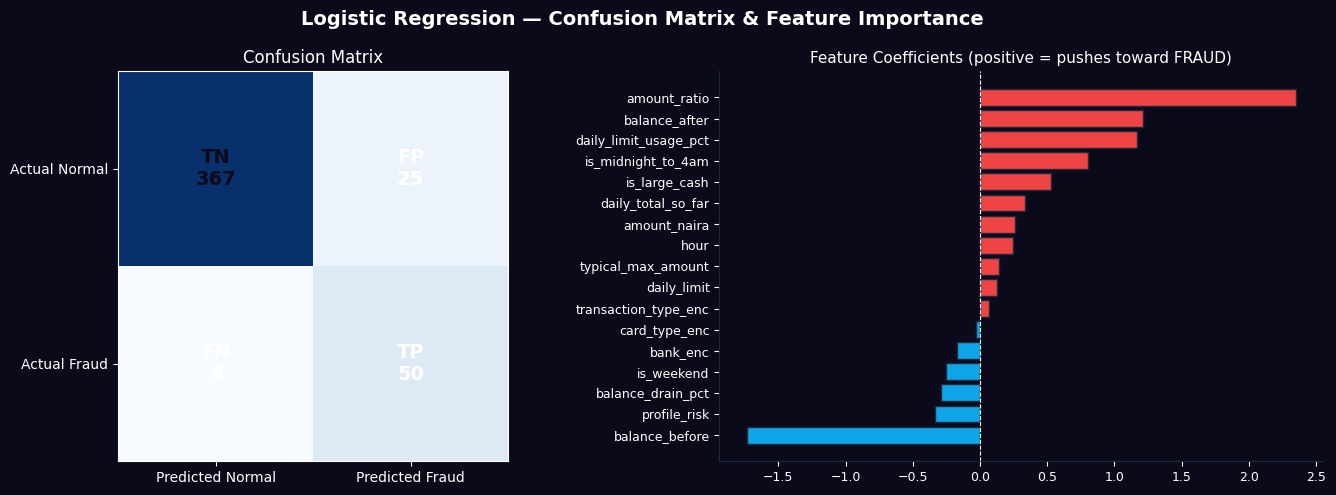


Top 5 features pushing toward FRAUD (positive coefficients):
  +2.347  →  amount_ratio
  +1.214  →  balance_after
  +1.168  →  daily_limit_usage_pct
  +0.801  →  is_midnight_to_4am
  +0.531  →  is_large_cash

Top 5 features pushing toward NORMAL (negative coefficients):
   -1.733  →  balance_before
   -0.333  →  profile_risk
   -0.289  →  balance_drain_pct
   -0.253  →  is_weekend
   -0.170  →  bank_enc


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3.2 — CONFUSION MATRIX + FEATURE COEFFICIENTS
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0A0A1A')
fig.suptitle('Logistic Regression — Confusion Matrix & Feature Importance',
             color='white', fontsize=14, fontweight='bold')

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_lr)
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_facecolor('#0A0A1A')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Predicted Normal','Predicted Fraud'], color='white')
axes[0].set_yticklabels(['Actual Normal','Actual Fraud'], color='white')
axes[0].set_title('Confusion Matrix', color='white', fontsize=12)
for i in range(2):
    for j in range(2):
        label = ['TN','FP','FN','TP'][i*2+j]
        axes[0].text(j, i, f'{label}\n{cm[i,j]}',
                    ha='center', va='center',
                    color='white' if cm[i,j] < cm.max()/2 else '#0A0A1A',
                    fontsize=14, fontweight='bold')

# ── Feature Coefficients ──────────────────────────────────────────────────────
coeffs = pd.Series(lr_model.coef_[0], index=FEATURES).sort_values()
colors = [PALETTE['fraud'] if v > 0 else PALETTE['normal'] for v in coeffs.values]
axes[1].barh(coeffs.index, coeffs.values, color=colors, edgecolor='#1E293B')
axes[1].set_title('Feature Coefficients (positive = pushes toward FRAUD)',
                  color='white', fontsize=11)
axes[1].set_facecolor('#0A0A1A')
axes[1].tick_params(colors='white', labelsize=9)
axes[1].spines['bottom'].set_color('#1E293B')
axes[1].spines['left'].set_color('#1E293B')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].axvline(x=0, color='white', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

print()
print("Top 5 features pushing toward FRAUD (positive coefficients):")
top5_fraud = coeffs.nlargest(5)
for feat, coeff in top5_fraud.items():
    print(f"  +{coeff:.3f}  →  {feat}")

print()
print("Top 5 features pushing toward NORMAL (negative coefficients):")
top5_normal = coeffs.nsmallest(5)
for feat, coeff in top5_normal.items():
    print(f"   {coeff:.3f}  →  {feat}")


---
## 🌳 Section 4 — Decision Tree

A **Decision Tree** learns a series of if/else questions about the features that best separate fraud from normal transactions. It is the algorithm closest to what the Rule-Based system did — but the computer discovers the rules automatically.

### How It Works
```
Is amount_ratio > 3.1?
  → YES: Is hour < 4.5?
      → YES: Is balance_drain_pct > 85?  → FRAUD (99%)
      → NO:  FRAUD (78%)
  → NO:  NORMAL (94%)
```

### Why Use It?
- Fully explainable — you can read the tree as a set of rules
- Shows you WHICH features the algorithm chose and at what thresholds
- Directly comparable to the manual rules we wrote in the Rule-Based notebook


In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 — DECISION TREE CLASSIFIER
# ─────────────────────────────────────────────────────────────────────────────

dt_model = DecisionTreeClassifier(
    max_depth=6,             # limit tree depth to prevent overfitting
    min_samples_leaf=10,     # each leaf must have at least 10 samples
    class_weight='balanced', # handle imbalance
    random_state=42,
    criterion='gini'         # Gini impurity: measures how mixed classes are in each node
)

# Decision trees do NOT need scaled features (they split on raw values)
dt_model.fit(X_train_orig, y_train)

y_pred_dt = dt_model.predict(X_test_orig)
y_prob_dt = dt_model.predict_proba(X_test_orig)[:, 1]

precision_dt = precision_score(y_test, y_pred_dt)
recall_dt    = recall_score(y_test, y_pred_dt)
f1_dt        = f1_score(y_test, y_pred_dt)
roc_auc_dt   = roc_auc_score(y_test, y_prob_dt)

print("=" * 60)
print("  DECISION TREE — RESULTS")
print("=" * 60)
print()
print(classification_report(y_test, y_pred_dt, target_names=['Normal','Fraud']))
print(f"  Precision  : {precision_dt*100:.1f}%")
print(f"  Recall     : {recall_dt*100:.1f}%")
print(f"  F1 Score   : {f1_dt*100:.1f}%")
print(f"  ROC-AUC    : {roc_auc_dt:.4f}")
print(f"  Tree depth : {dt_model.get_depth()} levels")
print(f"  Leaves     : {dt_model.get_n_leaves()} terminal nodes")


  DECISION TREE — RESULTS

              precision    recall  f1-score   support

      Normal       0.99      0.94      0.96       392
       Fraud       0.68      0.93      0.78        54

    accuracy                           0.94       446
   macro avg       0.83      0.93      0.87       446
weighted avg       0.95      0.94      0.94       446

  Precision  : 67.6%
  Recall     : 92.6%
  F1 Score   : 78.1%
  ROC-AUC    : 0.9568
  Tree depth : 6 levels
  Leaves     : 19 terminal nodes


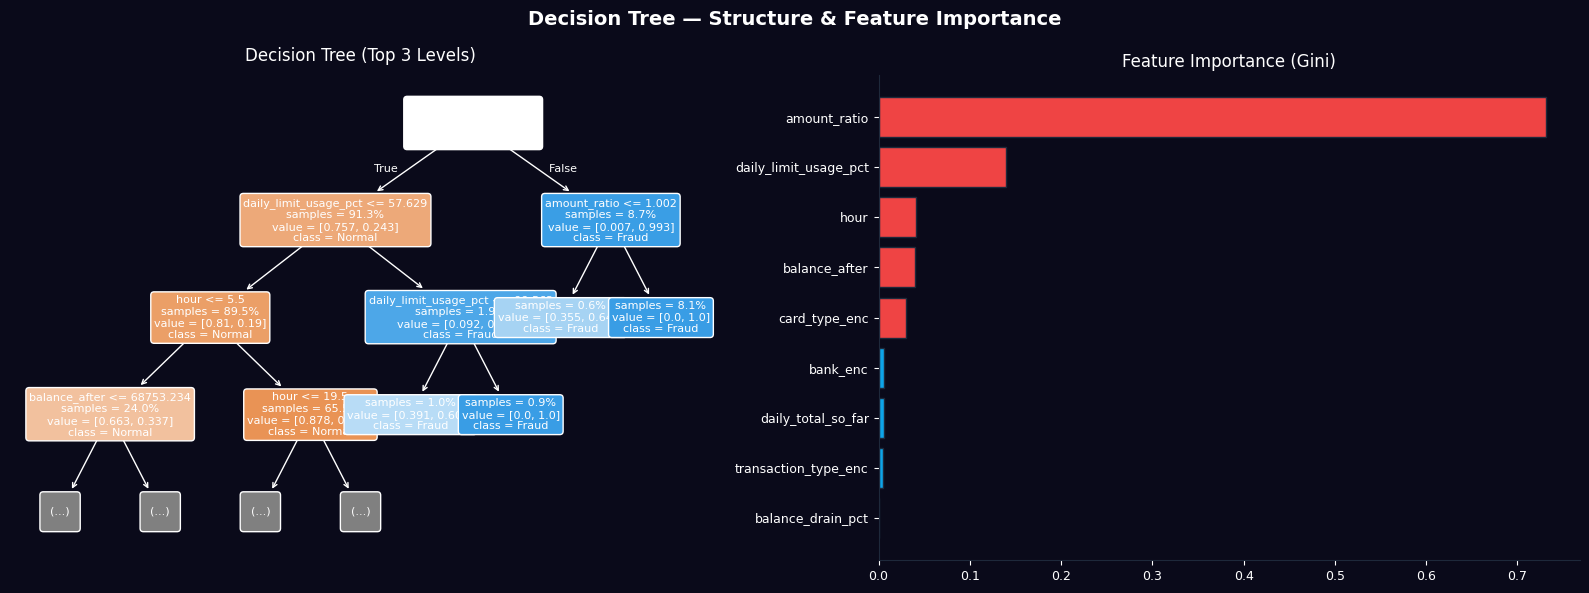

DECISION TREE RULES (Top 4 Levels):
-----------------------------------------------------------------
|--- amount_ratio <= 0.99
|   |--- daily_limit_usage_pct <= 57.63
|   |   |--- hour <= 5.50
|   |   |   |--- balance_after <= 68753.23
|   |   |   |   |--- card_type_enc <= 0.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- card_type_enc >  0.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- balance_after >  68753.23
|   |   |   |   |--- card_type_enc <= 2.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- card_type_enc >  2.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |--- hour >  5.50
|   |   |   |--- hour <= 19.50
|   |   |   |   |--- balance_after <= 36493.99
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- balance_after >  36493.99
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- hour >  19.50
|   |   |   |   |--- daily_total_so_far <= 16471

In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.2 — VISUALISE THE DECISION TREE (first 3 levels)
#
# We show only the top 3 levels — the full tree would be too large to read.
# These top levels contain the MOST IMPORTANT decision rules.
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0A0A1A')
fig.suptitle('Decision Tree — Structure & Feature Importance',
             color='white', fontsize=14, fontweight='bold')

# ── Tree visualisation (top 3 levels) ────────────────────────────────────────
plot_tree(
    dt_model,
    max_depth=3,                    # show only top 3 levels
    feature_names=FEATURES,
    class_names=['Normal','Fraud'],
    filled=True,                    # colour nodes by majority class
    rounded=True,
    fontsize=8,
    ax=axes[0],
    impurity=False,
    proportion=True
)
axes[0].set_title('Decision Tree (Top 3 Levels)',
                  color='white', fontsize=12, pad=10)
axes[0].set_facecolor('#0A0A1A')

# ── Feature importance ────────────────────────────────────────────────────────
importance_dt = pd.Series(dt_model.feature_importances_, index=FEATURES)
importance_dt = importance_dt[importance_dt > 0].sort_values(ascending=True)
colors_imp = [PALETTE['fraud'] if i >= len(importance_dt)-5 else PALETTE['normal']
              for i in range(len(importance_dt))]
axes[1].barh(importance_dt.index, importance_dt.values,
             color=colors_imp, edgecolor='#1E293B')
axes[1].set_title('Feature Importance (Gini)',
                  color='white', fontsize=12)
axes[1].set_facecolor('#0A0A1A')
axes[1].tick_params(colors='white', labelsize=9)
for spine in ['top','right']: axes[1].spines[spine].set_visible(False)
for spine in ['bottom','left']: axes[1].spines[spine].set_color('#1E293B')

plt.tight_layout()
plt.show()

# Print the tree as text (first 4 levels)
print("DECISION TREE RULES (Top 4 Levels):")
print("-" * 65)
tree_text = export_text(dt_model, feature_names=FEATURES, max_depth=4)
print(tree_text[:2000])
print("... (tree continues)")


---
## 🌲🌲🌲 Section 5 — Random Forest

**Random Forest** builds **many decision trees** (100 by default) and combines their predictions by **majority vote**. It is one of the most reliable algorithms in all of machine learning.

### How It Works
1. Create 100 different decision trees, each trained on a **random subset** of the data
2. Each tree also uses only a **random subset of features** at each split
3. For any new transaction, all 100 trees predict independently
4. Final prediction = majority vote: if 72 trees say FRAUD and 28 say NORMAL → **FRAUD**

### Why It Beats a Single Decision Tree
- **Variance reduction**: one tree can overfit; 100 trees cancel each other's errors
- **Robustness**: works well even with messy, noisy data
- **Feature importance**: aggregated across all 100 trees → more reliable than one tree


In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 — RANDOM FOREST CLASSIFIER
# ─────────────────────────────────────────────────────────────────────────────

rf_model = RandomForestClassifier(
    n_estimators=200,        # build 200 trees (more trees = more stable predictions)
    max_depth=10,            # each tree can go up to 10 levels deep
    min_samples_leaf=5,      # each leaf needs at least 5 samples
    class_weight='balanced', # handle imbalance — fraud mistakes cost more
    random_state=42,
    n_jobs=-1                # use all available CPU cores for speed
)

# Random Forest does NOT need scaled features
rf_model.fit(X_train_orig, y_train)

y_pred_rf = rf_model.predict(X_test_orig)
y_prob_rf = rf_model.predict_proba(X_test_orig)[:, 1]

precision_rf = precision_score(y_test, y_pred_rf)
recall_rf    = recall_score(y_test, y_pred_rf)
f1_rf        = f1_score(y_test, y_pred_rf)
roc_auc_rf   = roc_auc_score(y_test, y_prob_rf)

print("=" * 60)
print("  RANDOM FOREST — RESULTS  (200 trees)")
print("=" * 60)
print()
print(classification_report(y_test, y_pred_rf, target_names=['Normal','Fraud']))
print(f"  Precision  : {precision_rf*100:.1f}%")
print(f"  Recall     : {recall_rf*100:.1f}%")
print(f"  F1 Score   : {f1_rf*100:.1f}%")
print(f"  ROC-AUC    : {roc_auc_rf:.4f}")


  RANDOM FOREST — RESULTS  (200 trees)

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       392
       Fraud       0.91      0.93      0.92        54

    accuracy                           0.98       446
   macro avg       0.95      0.96      0.95       446
weighted avg       0.98      0.98      0.98       446

  Precision  : 90.9%
  Recall     : 92.6%
  F1 Score   : 91.7%
  ROC-AUC    : 0.9693


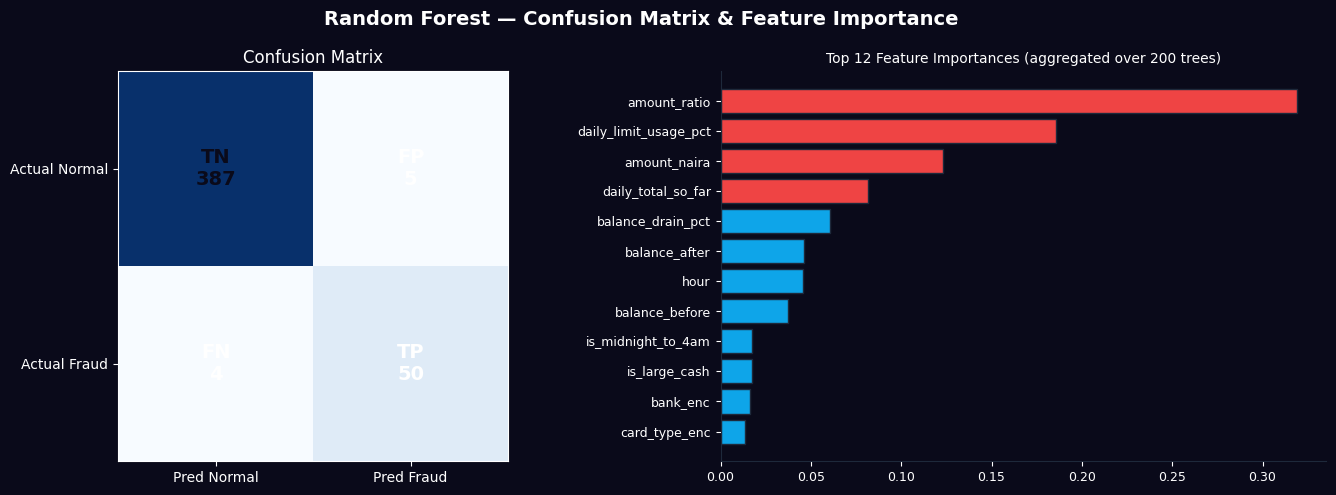

Top 5 Most Important Features (Random Forest):
  amount_ratio                 0.3193  ███████████████████████████████████████████████████████████████
  daily_limit_usage_pct        0.1856  █████████████████████████████████████
  amount_naira                 0.1230  ████████████████████████
  daily_total_so_far           0.0816  ████████████████
  balance_drain_pct            0.0606  ████████████


In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5.2 — RANDOM FOREST: CONFUSION MATRIX + FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0A0A1A')
fig.suptitle('Random Forest — Confusion Matrix & Feature Importance',
             color='white', fontsize=14, fontweight='bold')

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_rf)
axes[0].imshow(cm, cmap='Blues')
axes[0].set_facecolor('#0A0A1A')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Pred Normal','Pred Fraud'], color='white')
axes[0].set_yticklabels(['Actual Normal','Actual Fraud'], color='white')
axes[0].set_title('Confusion Matrix', color='white', fontsize=12)
for i in range(2):
    for j in range(2):
        label = ['TN','FP','FN','TP'][i*2+j]
        axes[0].text(j, i, f'{label}\n{cm[i,j]}',
                    ha='center', va='center',
                    color='white' if cm[i,j] < cm.max()/2 else '#0A0A1A',
                    fontsize=14, fontweight='bold')

# ── Feature Importance ────────────────────────────────────────────────────────
importance_rf = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
top_n = 12
importance_rf = importance_rf.tail(top_n)
bar_colors = [PALETTE['fraud'] if v >= importance_rf.quantile(0.7) else PALETTE['normal']
              for v in importance_rf.values]
axes[1].barh(importance_rf.index, importance_rf.values, color=bar_colors, edgecolor='#1E293B')
axes[1].set_title(f'Top {top_n} Feature Importances (aggregated over 200 trees)',
                  color='white', fontsize=10)
axes[1].set_facecolor('#0A0A1A')
axes[1].tick_params(colors='white', labelsize=9)
for spine in ['top','right']: axes[1].spines[spine].set_visible(False)
for spine in ['bottom','left']: axes[1].spines[spine].set_color('#1E293B')

plt.tight_layout()
plt.show()

print("Top 5 Most Important Features (Random Forest):")
for feat, imp in importance_rf.nlargest(5).items():
    bar = '█' * int(imp * 200)
    print(f"  {feat:<28} {imp:.4f}  {bar}")


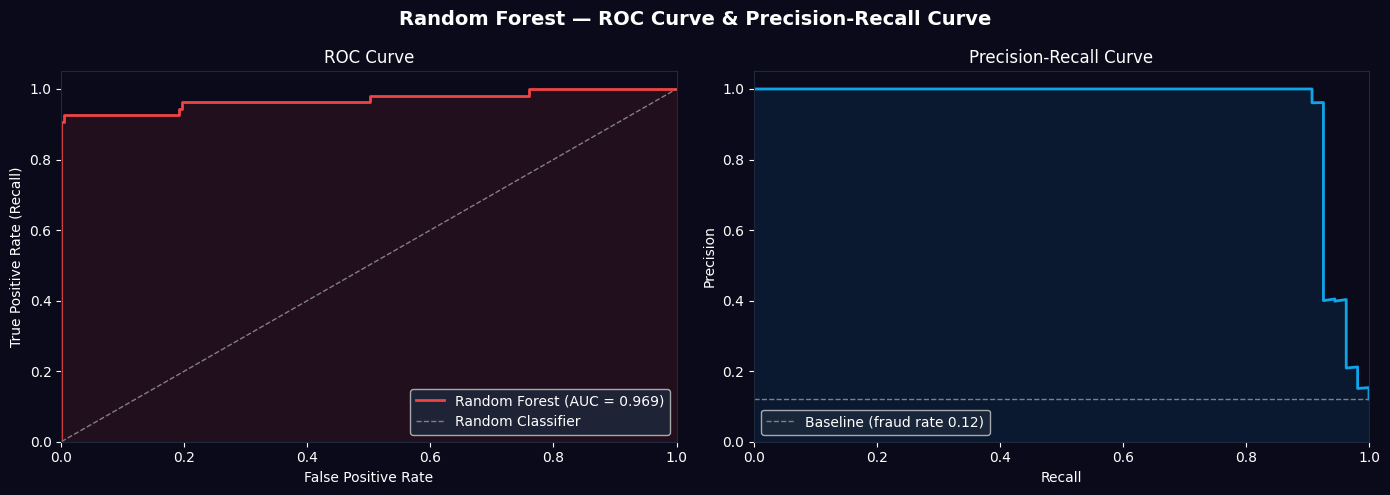

In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5.3 — ROC CURVE & PRECISION-RECALL CURVE
#
# ROC Curve: plots True Positive Rate vs False Positive Rate at every threshold.
# AUC = Area Under the Curve. Perfect model = 1.0. Random = 0.5.
#
# Precision-Recall Curve: better than ROC when classes are imbalanced.
# Shows the trade-off between precision and recall at each threshold.
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0A0A1A')
fig.suptitle('Random Forest — ROC Curve & Precision-Recall Curve',
             color='white', fontsize=14, fontweight='bold')

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob_rf)
axes[0].plot(fpr, tpr, color=PALETTE['fraud'], linewidth=2,
             label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
axes[0].plot([0,1],[0,1], color='gray', linestyle='--', linewidth=1, label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color=PALETTE['fraud'])
axes[0].set_xlabel('False Positive Rate', color='white')
axes[0].set_ylabel('True Positive Rate (Recall)', color='white')
axes[0].set_title('ROC Curve', color='white', fontsize=12)
axes[0].set_facecolor('#0A0A1A')
axes[0].tick_params(colors='white')
axes[0].legend(facecolor='#1E293B', labelcolor='white')
for spine in ['bottom','left','top','right']: axes[0].spines[spine].set_color('#1E293B')
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.05])

# ── Precision-Recall Curve ────────────────────────────────────────────────────
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob_rf)
axes[1].plot(recall_curve, precision_curve, color=PALETTE['normal'], linewidth=2)
baseline = y_test.mean()
axes[1].axhline(y=baseline, color='gray', linestyle='--', linewidth=1,
                label=f'Baseline (fraud rate {baseline:.2f})')
axes[1].fill_between(recall_curve, precision_curve, alpha=0.1, color=PALETTE['normal'])
axes[1].set_xlabel('Recall', color='white')
axes[1].set_ylabel('Precision', color='white')
axes[1].set_title('Precision-Recall Curve', color='white', fontsize=12)
axes[1].set_facecolor('#0A0A1A')
axes[1].tick_params(colors='white')
axes[1].legend(facecolor='#1E293B', labelcolor='white')
for spine in ['bottom','left','top','right']: axes[1].spines[spine].set_color('#1E293B')
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()


---
## ⚡ Section 6 — XGBoost (Gradient Boosting)

**XGBoost** (Extreme Gradient Boosting) is the **industry standard for fraud detection** at major banks and fintech companies worldwide. It wins most structured data competitions on Kaggle.

### How It Works (Boosting vs Bagging)
Random Forest uses **Bagging**: build many trees **in parallel**, all independent.  
XGBoost uses **Boosting**: build trees **sequentially**, each tree fixing the errors of the previous one.

```
Tree 1: predicts poorly on 300 cases → marks them as hard
Tree 2: focuses on those 300 hard cases → still gets 80 wrong
Tree 3: focuses on those 80 cases → and so on...
Final: all trees combined → very high accuracy
```

### Why XGBoost for Fraud?
- Handles imbalanced data better than most algorithms
- Built-in regularisation prevents overfitting
- Scale-invariant (no need to normalise features)
- Extremely fast due to parallel tree construction


In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6 — XGBOOST (GRADIENT BOOSTING)
# ─────────────────────────────────────────────────────────────────────────────

# Calculate scale_pos_weight to handle imbalance
# scale_pos_weight = (count of normal) / (count of fraud)
# This tells XGBoost to penalise missing fraud cases more heavily
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}  "
      f"(for every fraud missed, penalise {scale_pos_weight:.1f}× more)")
print()

if XGBOOST_AVAILABLE:
    xgb_model = XGBClassifier(
        n_estimators=300,               # 300 boosting rounds
        max_depth=5,                    # each tree max 5 levels
        learning_rate=0.05,             # small steps = better generalisation
        subsample=0.8,                  # use 80% of data per tree (reduces overfitting)
        colsample_bytree=0.8,           # use 80% of features per tree
        scale_pos_weight=scale_pos_weight,  # handle class imbalance
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
else:
    # Gradient Boosting from sklearn as substitute
    from sklearn.ensemble import GradientBoostingClassifier
    xgb_model = GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=42
    )

xgb_model.fit(X_train_orig, y_train)

y_pred_xgb = xgb_model.predict(X_test_orig)
y_prob_xgb = xgb_model.predict_proba(X_test_orig)[:, 1]

precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb    = recall_score(y_test, y_pred_xgb)
f1_xgb        = f1_score(y_test, y_pred_xgb)
roc_auc_xgb   = roc_auc_score(y_test, y_prob_xgb)

print("=" * 60)
print("  XGBOOST — RESULTS  (300 boosting rounds)")
print("=" * 60)
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Normal','Fraud']))
print(f"  Precision  : {precision_xgb*100:.1f}%")
print(f"  Recall     : {recall_xgb*100:.1f}%")
print(f"  F1 Score   : {f1_xgb*100:.1f}%")
print(f"  ROC-AUC    : {roc_auc_xgb:.4f}")


scale_pos_weight = 7.25  (for every fraud missed, penalise 7.3× more)

  XGBOOST — RESULTS  (300 boosting rounds)

              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99       392
       Fraud       0.88      0.93      0.90        54

    accuracy                           0.98       446
   macro avg       0.93      0.95      0.94       446
weighted avg       0.98      0.98      0.98       446

  Precision  : 87.7%
  Recall     : 92.6%
  F1 Score   : 90.1%
  ROC-AUC    : 0.9666


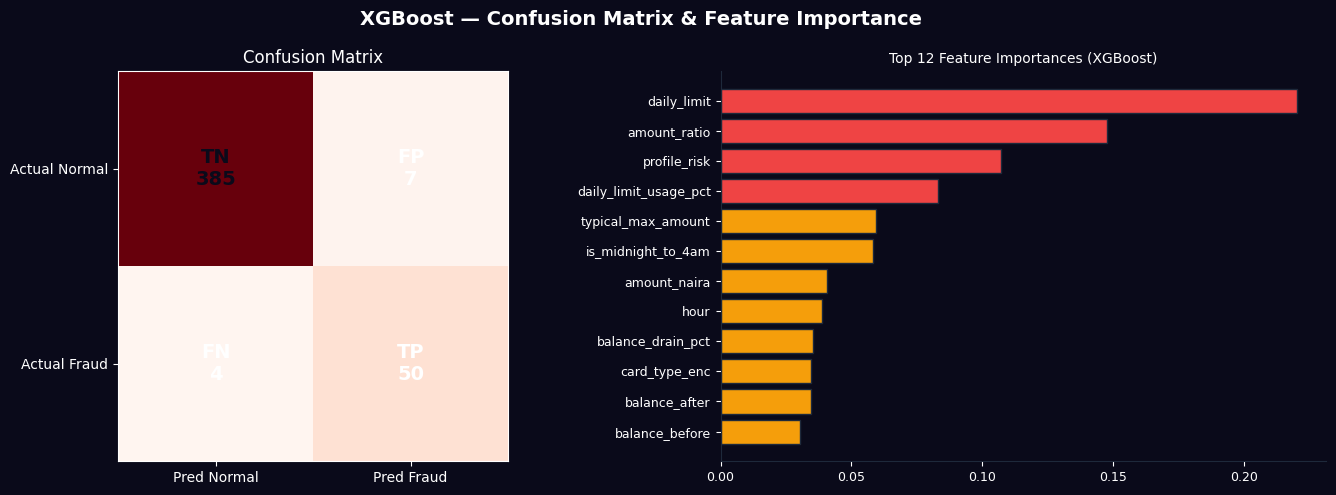

XGBoost Top 5 Most Important Features:
  daily_limit                  0.2206  ████████████████████████████████████████████
  amount_ratio                 0.1478  █████████████████████████████
  profile_risk                 0.1071  █████████████████████
  daily_limit_usage_pct        0.0832  ████████████████
  typical_max_amount           0.0596  ███████████


In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6.2 — XGBOOST CONFUSION MATRIX + FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0A0A1A')
fig.suptitle('XGBoost — Confusion Matrix & Feature Importance',
             color='white', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
axes[0].imshow(cm, cmap='Reds')
axes[0].set_facecolor('#0A0A1A')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Pred Normal','Pred Fraud'], color='white')
axes[0].set_yticklabels(['Actual Normal','Actual Fraud'], color='white')
axes[0].set_title('Confusion Matrix', color='white', fontsize=12)
for i in range(2):
    for j in range(2):
        label = ['TN','FP','FN','TP'][i*2+j]
        axes[0].text(j, i, f'{label}\n{cm[i,j]}',
                    ha='center', va='center',
                    color='white' if cm[i,j] < cm.max()/2 else '#0A0A1A',
                    fontsize=14, fontweight='bold')

# Feature Importance
importance_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
top_n = 12
importance_xgb_top = importance_xgb.tail(top_n)
bar_colors = [PALETTE['fraud'] if v >= importance_xgb_top.quantile(0.7) else PALETTE['gold']
              for v in importance_xgb_top.values]
try:
    bar_colors = [PALETTE['fraud'] if v >= importance_xgb_top.quantile(0.7) else PALETTE['gold']
                  for v in importance_xgb_top.values]
except: pass
axes[1].barh(importance_xgb_top.index, importance_xgb_top.values,
             color=bar_colors, edgecolor='#1E293B')
axes[1].set_title(f'Top {top_n} Feature Importances (XGBoost)',
                  color='white', fontsize=10)
axes[1].set_facecolor('#0A0A1A')
axes[1].tick_params(colors='white', labelsize=9)
for spine in ['top','right']: axes[1].spines[spine].set_visible(False)
for spine in ['bottom','left']: axes[1].spines[spine].set_color('#1E293B')

plt.tight_layout()
plt.show()

print("XGBoost Top 5 Most Important Features:")
for feat, imp in importance_xgb.nlargest(5).items():
    bar = '█' * int(imp * 200)
    print(f"  {feat:<28} {imp:.4f}  {bar}")


---
## 🔍 Section 7 — Isolation Forest (Unsupervised)

All previous models were **supervised** — they learned from labelled data (`is_fraud_flag`).

**Isolation Forest** is **unsupervised** — it detects anomalies WITHOUT knowing which transactions are fraud. It finds transactions that are **different from the majority** purely from their feature values.

### How It Works
1. Pick a random feature
2. Pick a random split value for that feature
3. Keep splitting randomly until the transaction is **isolated** (alone in its node)
4. Transactions that get isolated very **quickly** (few splits needed) are anomalies — they are different from everything else

### Why Is This Powerful?
- **No labels needed** — works on completely new fraud types that have never been seen before
- Real-world use: banks deploy Isolation Forest alongside rule engines to catch **novel** fraud patterns that no one has written rules for yet


In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7 — ISOLATION FOREST (UNSUPERVISED ANOMALY DETECTION)
# ─────────────────────────────────────────────────────────────────────────────

# contamination = estimated fraction of anomalies in the dataset
# We know from the data that ~12.1% are fraud, so we set contamination=0.121
fraud_rate = y.mean()

iso_model = IsolationForest(
    n_estimators=200,           # 200 isolation trees
    contamination=fraud_rate,   # expected fraction of anomalies
    random_state=42,
    n_jobs=-1
)

# Key difference: fit on ALL features including test set (unsupervised)
# Isolation Forest does not use labels during training
iso_model.fit(X.values)

# Predict: Isolation Forest outputs -1 for anomaly, +1 for normal
iso_raw = iso_model.predict(X_test_orig)

# Convert to 0/1: -1 (anomaly) → 1 (fraud), +1 (normal) → 0 (normal)
y_pred_iso = (iso_raw == -1).astype(int)

# Anomaly scores: more negative = more anomalous
iso_scores = iso_model.decision_function(X_test_orig)
# Convert so higher score = more fraud-like (flip the sign)
y_prob_iso = -iso_scores

precision_iso = precision_score(y_test, y_pred_iso, zero_division=0)
recall_iso    = recall_score(y_test, y_pred_iso, zero_division=0)
f1_iso        = f1_score(y_test, y_pred_iso, zero_division=0)
roc_auc_iso   = roc_auc_score(y_test, y_prob_iso)

print("=" * 60)
print("  ISOLATION FOREST — RESULTS  (unsupervised — no labels used)")
print("=" * 60)
print()
print(classification_report(y_test, y_pred_iso, target_names=['Normal','Fraud'],
                             zero_division=0))
print(f"  Precision  : {precision_iso*100:.1f}%")
print(f"  Recall     : {recall_iso*100:.1f}%")
print(f"  F1 Score   : {f1_iso*100:.1f}%")
print(f"  ROC-AUC    : {roc_auc_iso:.4f}")
print()
print("⚠️  Note: Isolation Forest typically scores lower than supervised models.")
print("   This is expected — it has no fraud labels to learn from.")
print("   Its VALUE is detecting novel, unseen fraud patterns.")


  ISOLATION FOREST — RESULTS  (unsupervised — no labels used)

              precision    recall  f1-score   support

      Normal       0.94      0.93      0.94       392
       Fraud       0.54      0.59      0.57        54

    accuracy                           0.89       446
   macro avg       0.74      0.76      0.75       446
weighted avg       0.89      0.89      0.89       446

  Precision  : 54.2%
  Recall     : 59.3%
  F1 Score   : 56.6%
  ROC-AUC    : 0.8972

⚠️  Note: Isolation Forest typically scores lower than supervised models.
   This is expected — it has no fraud labels to learn from.
   Its VALUE is detecting novel, unseen fraud patterns.


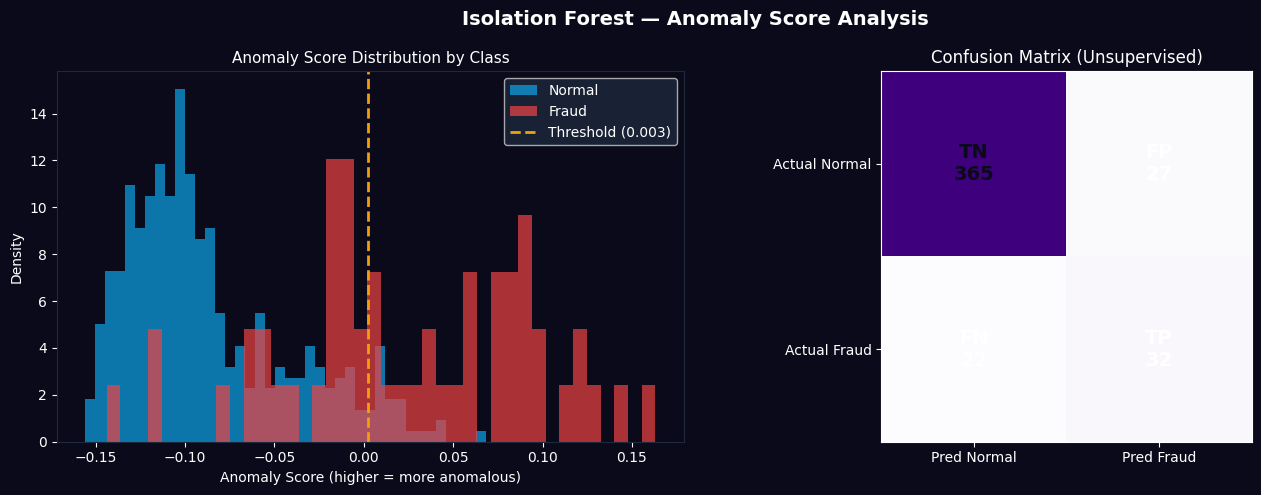

In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7.2 — ISOLATION FOREST: ANOMALY SCORE DISTRIBUTION
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0A0A1A')
fig.suptitle('Isolation Forest — Anomaly Score Analysis',
             color='white', fontsize=14, fontweight='bold')

# ── Anomaly score distribution ────────────────────────────────────────────────
test_scores = pd.Series(-iso_model.decision_function(X_test_orig), name='anomaly_score')
test_labels = y_test.values

axes[0].hist(test_scores[test_labels == 0], bins=40, color=PALETTE['normal'],
             alpha=0.7, label='Normal', density=True)
axes[0].hist(test_scores[test_labels == 1], bins=40, color=PALETTE['fraud'],
             alpha=0.7, label='Fraud', density=True)
# Find threshold
threshold_iso = np.percentile(test_scores, (1 - fraud_rate) * 100)
axes[0].axvline(x=threshold_iso, color=PALETTE['gold'], linestyle='--',
                linewidth=2, label=f'Threshold ({threshold_iso:.3f})')
axes[0].set_xlabel('Anomaly Score (higher = more anomalous)', color='white')
axes[0].set_ylabel('Density', color='white')
axes[0].set_title('Anomaly Score Distribution by Class', color='white', fontsize=11)
axes[0].set_facecolor('#0A0A1A')
axes[0].tick_params(colors='white')
axes[0].legend(facecolor='#1E293B', labelcolor='white')
for s in ['top','right','bottom','left']: axes[0].spines[s].set_color('#1E293B')

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_iso)
axes[1].imshow(cm, cmap='Purples')
axes[1].set_facecolor('#0A0A1A')
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['Pred Normal','Pred Fraud'], color='white')
axes[1].set_yticklabels(['Actual Normal','Actual Fraud'], color='white')
axes[1].set_title('Confusion Matrix (Unsupervised)', color='white', fontsize=12)
for i in range(2):
    for j in range(2):
        label = ['TN','FP','FN','TP'][i*2+j]
        axes[1].text(j, i, f'{label}\n{cm[i,j]}',
                    ha='center', va='center',
                    color='white' if cm[i,j] < cm.max()/2 else '#0A0A1A',
                    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 📊 Section 8 — Model Comparison: Which Algorithm Wins?

We now put all four models side by side and compare them on every metric that matters for fraud detection.

### The Key Metrics for Fraud Detection

| Metric | Formula | Why It Matters |
|--------|---------|----------------|
| **Recall** | TP / (TP + FN) | Most important — % of real fraud caught. Missing fraud harms customers. |
| **Precision** | TP / (TP + FP) | % of alerts that are real fraud. Low precision = analyst fatigue. |
| **F1 Score** | 2×P×R / (P+R) | Balances precision and recall. Single best metric. |
| **ROC-AUC** | Area under ROC curve | Overall discrimination power. 1.0 = perfect, 0.5 = random. |


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8 — FULL MODEL COMPARISON
# ─────────────────────────────────────────────────────────────────────────────

results = {
    'Logistic Regression': {
        'precision': precision_lr, 'recall': recall_lr,
        'f1': f1_lr, 'roc_auc': roc_auc_lr,
        'y_pred': y_pred_lr, 'y_prob': y_prob_lr,
        'color': PALETTE['normal']
    },
    'Decision Tree': {
        'precision': precision_dt, 'recall': recall_dt,
        'f1': f1_dt, 'roc_auc': roc_auc_dt,
        'y_pred': y_pred_dt, 'y_prob': y_prob_dt,
        'color': PALETTE['purple']
    },
    'Random Forest': {
        'precision': precision_rf, 'recall': recall_rf,
        'f1': f1_rf, 'roc_auc': roc_auc_rf,
        'y_pred': y_pred_rf, 'y_prob': y_prob_rf,
        'color': PALETTE['green']
    },
    'XGBoost': {
        'precision': precision_xgb, 'recall': recall_xgb,
        'f1': f1_xgb, 'roc_auc': roc_auc_xgb,
        'y_pred': y_pred_xgb, 'y_prob': y_prob_xgb,
        'color': PALETTE['gold']
    },
    'Isolation Forest*': {
        'precision': precision_iso, 'recall': recall_iso,
        'f1': f1_iso, 'roc_auc': roc_auc_iso,
        'y_pred': y_pred_iso, 'y_prob': y_prob_iso,
        'color': PALETTE['fraud']
    },
}

# ── Summary table ─────────────────────────────────────────────────────────────
print("=" * 78)
print(f"  {'MODEL':<22}  {'PRECISION':>10}  {'RECALL':>8}  {'F1 SCORE':>10}  {'ROC-AUC':>9}")
print("=" * 78)

champion_model = None
champion_f1    = 0

for name, r in results.items():
    marker = " ← CHAMPION" if r['f1'] == max(res['f1'] for res in results.values()) else ""
    print(f"  {name:<22}  {r['precision']*100:>9.1f}%  {r['recall']*100:>7.1f}%  "
          f"{r['f1']*100:>9.1f}%  {r['roc_auc']:>9.4f}{marker}")
    if r['f1'] > champion_f1:
        champion_f1   = r['f1']
        champion_model = name

print("=" * 78)
print(f"  * Isolation Forest is unsupervised — it sees no fraud labels during training")
print()
print(f"  🏆 CHAMPION MODEL: {champion_model}")
print(f"     F1 Score: {champion_f1*100:.1f}%")


  MODEL                    PRECISION    RECALL    F1 SCORE    ROC-AUC
  Logistic Regression          66.7%     92.6%       77.5%     0.9669
  Decision Tree                67.6%     92.6%       78.1%     0.9568
  Random Forest                90.9%     92.6%       91.7%     0.9693 ← CHAMPION
  XGBoost                      87.7%     92.6%       90.1%     0.9666
  Isolation Forest*            54.2%     59.3%       56.6%     0.8972
  * Isolation Forest is unsupervised — it sees no fraud labels during training

  🏆 CHAMPION MODEL: Random Forest
     F1 Score: 91.7%


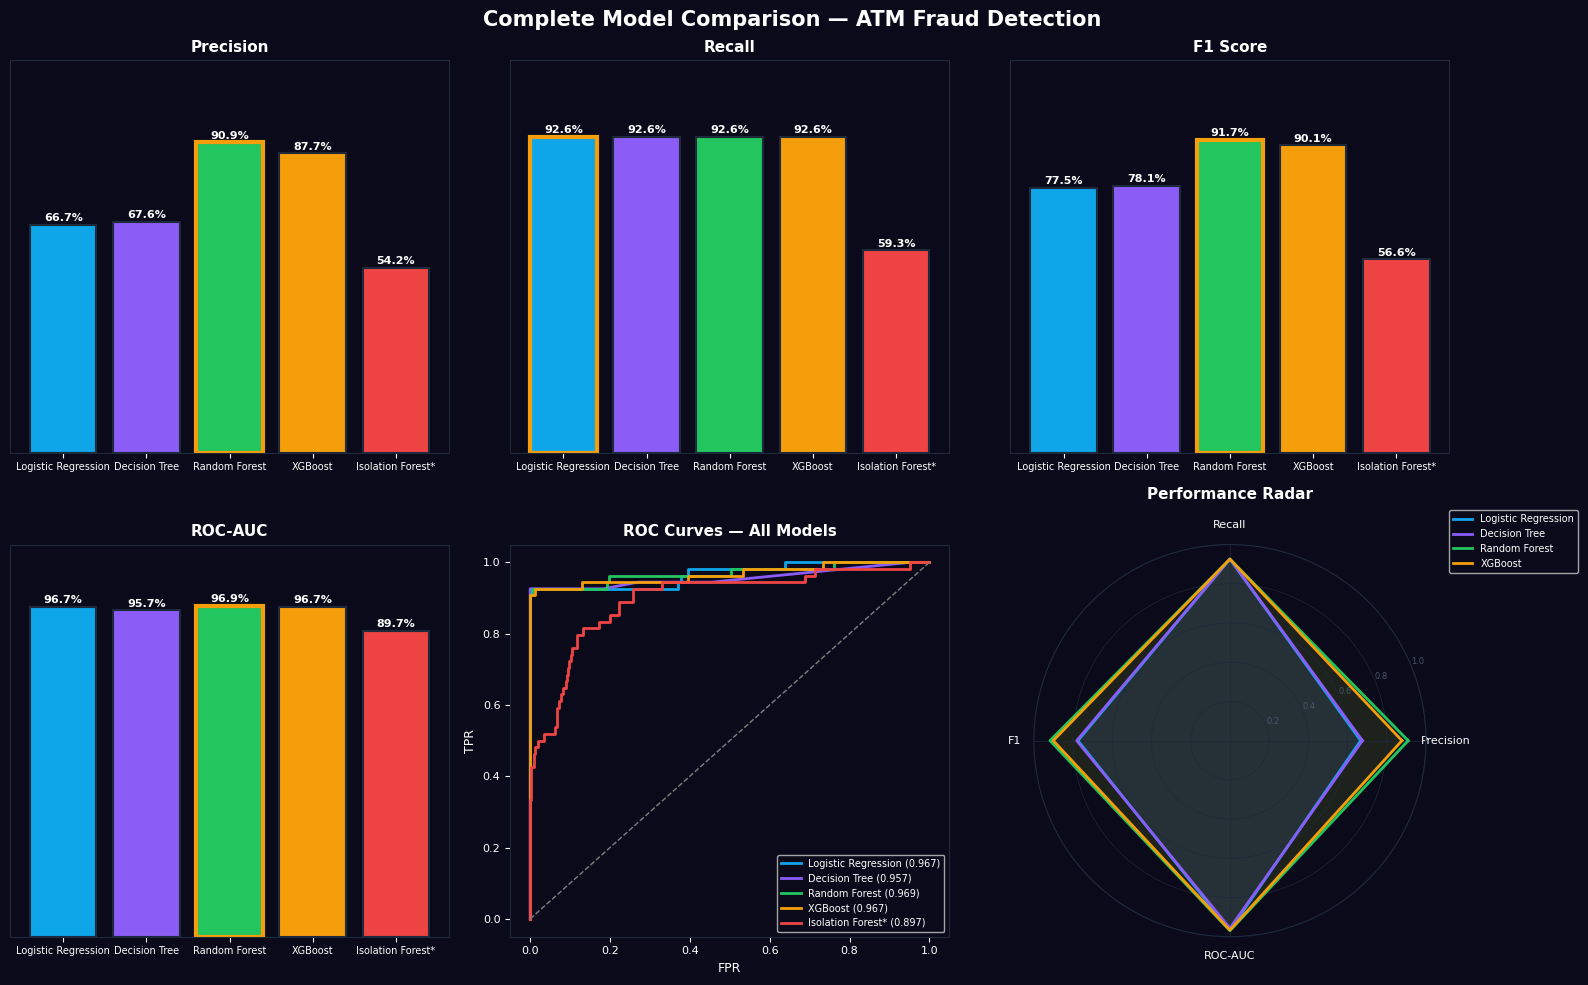

In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8.2 — VISUAL MODEL COMPARISON
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0A0A1A')
fig.suptitle('Complete Model Comparison — ATM Fraud Detection',
             color='white', fontsize=15, fontweight='bold', y=0.98)

# ── Metric bar charts ─────────────────────────────────────────────────────────
metrics_to_plot = ['precision', 'recall', 'f1', 'roc_auc']
metric_labels   = ['Precision', 'Recall', 'F1 Score', 'ROC-AUC']
model_names     = list(results.keys())
colors          = [r['color'] for r in results.values()]

for mi, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    ax = fig.add_subplot(2, 3, mi + 1)
    values = [results[m][metric] for m in model_names]
    bars = ax.bar(range(len(model_names)), values, color=colors, edgecolor='#1E293B', linewidth=1.5)
    # Highlight champion
    best_idx = values.index(max(values))
    bars[best_idx].set_edgecolor(PALETTE['gold'])
    bars[best_idx].set_linewidth(3)
    for i, (bar, val) in enumerate(zip(bars, values)):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.005,
                f'{val*100:.1f}%', ha='center', va='bottom',
                color='white', fontsize=8, fontweight='bold')
    ax.set_title(label, color='white', fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, color='white', fontsize=7)
    ax.set_ylim(0, 1.15)
    ax.set_facecolor('#0A0A1A')
    ax.tick_params(colors='white')
    ax.yaxis.set_visible(False)
    for s in ['top','right','bottom','left']: ax.spines[s].set_color('#1E293B')

# ── ROC curves (all models) ───────────────────────────────────────────────────
ax_roc = fig.add_subplot(2, 3, 5)
for name, r in results.items():
    try:
        fpr_c, tpr_c, _ = roc_curve(y_test, r['y_prob'])
        ax_roc.plot(fpr_c, tpr_c, color=r['color'], linewidth=2,
                    label=f'{name} ({r["roc_auc"]:.3f})')
    except: pass
ax_roc.plot([0,1],[0,1], color='gray', linestyle='--', linewidth=1)
ax_roc.set_xlabel('FPR', color='white', fontsize=9)
ax_roc.set_ylabel('TPR', color='white', fontsize=9)
ax_roc.set_title('ROC Curves — All Models', color='white', fontsize=11, fontweight='bold')
ax_roc.set_facecolor('#0A0A1A')
ax_roc.tick_params(colors='white', labelsize=8)
ax_roc.legend(facecolor='#0A0A1A', labelcolor='white', fontsize=7, loc='lower right')
for s in ['top','right','bottom','left']: ax_roc.spines[s].set_color('#1E293B')

# ── Radar chart ───────────────────────────────────────────────────────────────
ax_radar = fig.add_subplot(2, 3, 6, polar=True)
ax_radar.set_facecolor('#0A0A1A')
cats = ['Precision','Recall','F1','ROC-AUC']
N = len(cats)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for name, r in list(results.items())[:4]:
    values_radar = [r['precision'], r['recall'], r['f1'], r['roc_auc']]
    values_radar += values_radar[:1]
    ax_radar.plot(angles, values_radar, color=r['color'], linewidth=2,
                  linestyle='solid', label=name)
    ax_radar.fill(angles, values_radar, color=r['color'], alpha=0.08)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(cats, color='white', fontsize=8)
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax_radar.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], color='#475569', fontsize=6)
ax_radar.set_title('Performance Radar', color='white', fontsize=11,
                   fontweight='bold', pad=15)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1),
                facecolor='#0A0A1A', labelcolor='white', fontsize=7)
ax_radar.grid(color='#1E293B', linewidth=0.5)
ax_radar.spines['polar'].set_color('#1E293B')

plt.tight_layout()
plt.show()


---
## 🔬 Section 9 — Feature Importance: What Drives Fraud Detection?

Understanding which features drive predictions is essential for:
1. **Trust** — validating the model makes sense financially
2. **Compliance** — regulators require explainable decisions
3. **Improvement** — knowing what matters helps design better features

We compare feature importance across all three tree-based models.


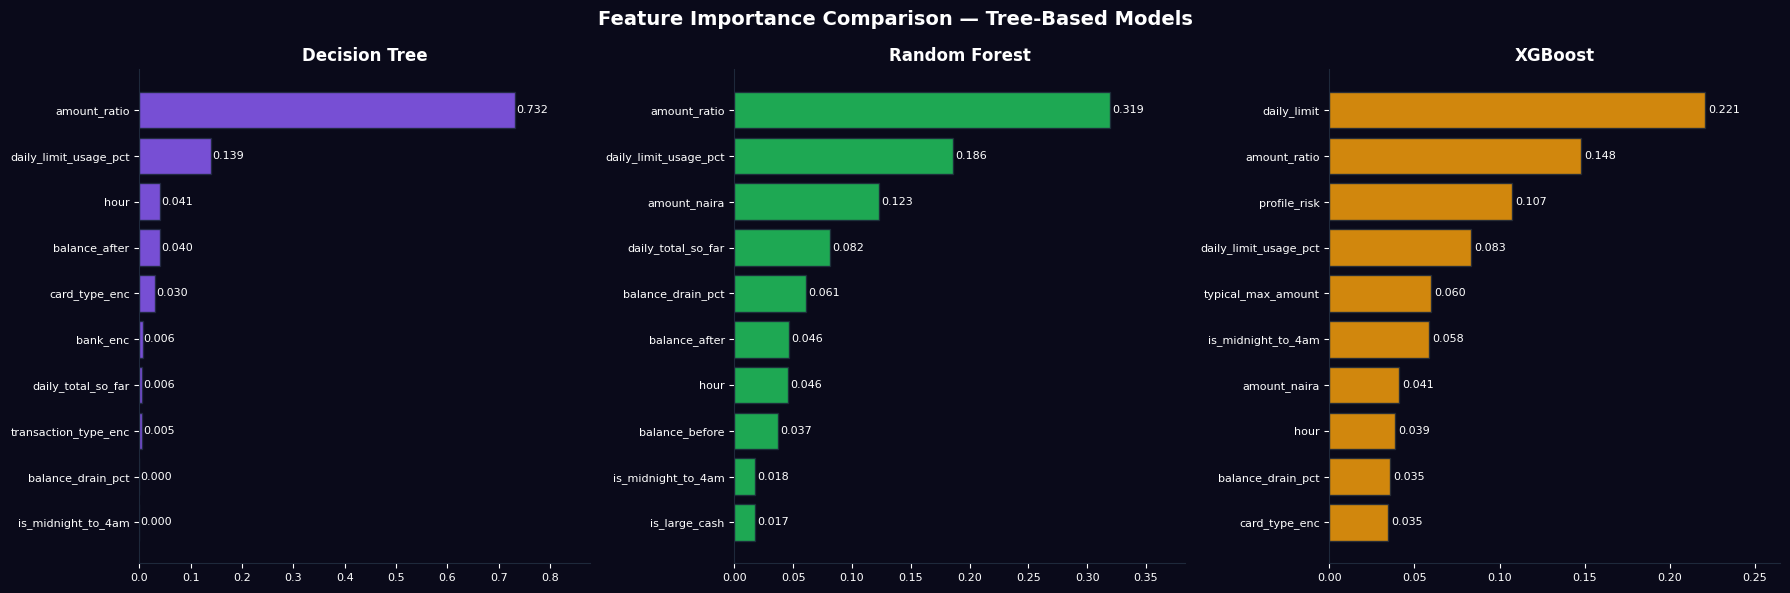

FEATURE IMPORTANCE CONSENSUS (average rank across all 3 tree models):
  # 1  amount_ratio                  0.3996  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████ ← TOP PREDICTOR
  # 2  daily_limit_usage_pct         0.1360  ████████████████████████████████████████ ← TOP PREDICTOR
  # 3  daily_limit                   0.0758  ██████████████████████ ← TOP PREDICTOR
  # 4  amount_naira                  0.0546  ████████████████
  # 5  hour                          0.0418  ████████████
  # 6  balance_after                 0.0404  ████████████
  # 7  daily_total_so_far            0.0385  ███████████
  # 8  profile_risk                  0.0379  ███████████
  # 9  balance_drain_pct             0.0321  █████████
  #10  card_type_enc                 0.0260  ███████
  #11  is_midnight_to_4am            0.0253  ███████
  #12  balance_before                0.0226  ██████
  #13  typical_max_amount            0.0223  ██████
  #14 

In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9 — COMPREHENSIVE FEATURE IMPORTANCE ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0A0A1A')
fig.suptitle('Feature Importance Comparison — Tree-Based Models',
             color='white', fontsize=14, fontweight='bold')

models_imp = [
    (dt_model,  'Decision Tree',  PALETTE['purple']),
    (rf_model,  'Random Forest',  PALETTE['green']),
    (xgb_model, 'XGBoost',        PALETTE['gold']),
]

all_importances = {}
for (model, name, color), ax in zip(models_imp, axes):
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    imp_top = imp.tail(10)
    all_importances[name] = imp

    bars = ax.barh(imp_top.index, imp_top.values, color=color,
                   alpha=0.85, edgecolor='#1E293B', linewidth=1)
    for bar, val in zip(bars, imp_top.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', color='white', fontsize=8)
    ax.set_title(name, color='white', fontsize=12, fontweight='bold')
    ax.set_facecolor('#0A0A1A')
    ax.tick_params(colors='white', labelsize=8)
    for s in ['top','right']: ax.spines[s].set_visible(False)
    for s in ['bottom','left']: ax.spines[s].set_color('#1E293B')
    ax.set_xlim(0, imp_top.max() * 1.2)

plt.tight_layout()
plt.show()

# ── Consensus: features important across all models ────────────────────────────
print("FEATURE IMPORTANCE CONSENSUS (average rank across all 3 tree models):")
print("=" * 60)
avg_importance = pd.DataFrame(all_importances).mean(axis=1).sort_values(ascending=False)
for i, (feat, score) in enumerate(avg_importance.items(), 1):
    bar = '█' * int(score * 300)
    marker = " ← TOP PREDICTOR" if i <= 3 else ""
    print(f"  #{i:>2}  {feat:<28}  {score:.4f}  {bar}{marker}")


---
## 🏆 Section 10 — Capstone: Full Production ML Pipeline

This is the session deliverable — a complete, production-ready fraud detection pipeline using the best model.

It does everything end-to-end:
1. Load data → 2. Engineer features → 3. Train/test split → 4. Train champion model → 5. Predict → 6. Score every transaction → 7. Generate fraud report → 8. Measure accuracy


In [47]:
# ═════════════════════════════════════════════════════════════════════════════
# CAPSTONE: FULL ML FRAUD DETECTION PIPELINE
# Zedcrest Capital | Algorithm-Based ATM Fraud Detection
# ═════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  SENTINEL ML — PRODUCTION PIPELINE")
print("  Algorithm-Based ATM Fraud Detection")
print("  Zedcrest Capital | Prodigy Training Hub")
print("=" * 65)
print()

# ── STEP 1: Identify champion ─────────────────────────────────────────────────
champion_name  = max(
    {'Logistic Regression': f1_lr, 'Decision Tree': f1_dt,
     'Random Forest': f1_rf, 'XGBoost': f1_xgb},
    key=lambda k: {'Logistic Regression': f1_lr, 'Decision Tree': f1_dt,
                   'Random Forest': f1_rf, 'XGBoost': f1_xgb}[k]
)
champion_model_obj = {'Logistic Regression': lr_model, 'Decision Tree': dt_model,
                      'Random Forest': rf_model, 'XGBoost': xgb_model}[champion_name]
champion_prob  = {'Logistic Regression': y_prob_lr, 'Decision Tree': y_prob_dt,
                  'Random Forest': y_prob_rf, 'XGBoost': y_prob_xgb}[champion_name]
champion_pred  = {'Logistic Regression': y_pred_lr, 'Decision Tree': y_pred_dt,
                  'Random Forest': y_pred_rf, 'XGBoost': y_pred_xgb}[champion_name]

print(f"  Champion Model : {champion_name}")
print(f"  F1 Score       : {max(f1_lr,f1_dt,f1_rf,f1_xgb)*100:.1f}%")
print()

# ── STEP 2: Score every transaction in the FULL dataset ──────────────────────
# Re-run on the FULL dataset (not just test set) for the final report
full_X   = df_ml[FEATURES].values
full_prob = champion_model_obj.predict_proba(full_X)[:, 1]
full_pred = champion_model_obj.predict(full_X)

df_output = df.copy()
df_output['ml_fraud_probability'] = (full_prob * 100).round(1)
df_output['ml_predicted_fraud']   = full_pred

def ml_risk_level(prob):
    if prob >= 85:  return '🔴 CRITICAL'
    elif prob >= 70: return '🟠 HIGH'
    elif prob >= 50: return '🟡 MEDIUM'
    elif prob >= 25: return '🔵 LOW'
    else:            return '🟢 CLEAR'

df_output['ml_risk_level'] = (df_output['ml_fraud_probability']).apply(ml_risk_level)

# ── STEP 3: Summary ───────────────────────────────────────────────────────────
total        = len(df_output)
ml_flagged   = df_output['ml_predicted_fraud'].sum()
tp_full = ((df_output['ml_predicted_fraud']==1) & (df_output['is_fraud']==1)).sum()
fp_full = ((df_output['ml_predicted_fraud']==1) & (df_output['is_fraud']==0)).sum()
fn_full = ((df_output['ml_predicted_fraud']==0) & (df_output['is_fraud']==1)).sum()
tn_full = ((df_output['ml_predicted_fraud']==0) & (df_output['is_fraud']==0)).sum()

prec = tp_full/(tp_full+fp_full)*100 if tp_full+fp_full>0 else 0
rec  = tp_full/(tp_full+fn_full)*100 if tp_full+fn_full>0 else 0
f1   = 2*prec*rec/(prec+rec) if prec+rec>0 else 0

print(f"  Total transactions scanned : {total:,}")
print(f"  ML flagged as fraud        : {ml_flagged:,}  ({ml_flagged/total*100:.1f}%)")
print()
print(f"  ✅ True Positives  : {tp_full:,}  (real fraud correctly caught)")
print(f"  ❌ False Positives : {fp_full:,}  (normal flagged incorrectly)")
print(f"  ⚠️  False Negatives : {fn_full:,}  (real fraud MISSED)")
print(f"  ✅ True Negatives  : {tn_full:,}  (normal correctly cleared)")
print()
print(f"  Precision : {prec:.1f}%")
print(f"  Recall    : {rec:.1f}%")
print(f"  F1 Score  : {f1:.1f}%")


  SENTINEL ML — PRODUCTION PIPELINE
  Algorithm-Based ATM Fraud Detection
  Zedcrest Capital | Prodigy Training Hub

  Champion Model : Random Forest
  F1 Score       : 91.7%

  Total transactions scanned : 2,229
  ML flagged as fraud        : 245  (11.0%)

  ✅ True Positives  : 235  (real fraud correctly caught)
  ❌ False Positives : 10  (normal flagged incorrectly)
  ⚠️  False Negatives : 35  (real fraud MISSED)
  ✅ True Negatives  : 1,949  (normal correctly cleared)

  Precision : 95.9%
  Recall    : 87.0%
  F1 Score  : 91.3%


In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# CAPSTONE STEP 4 — FRAUD REPORT
# Print top critical cases with all details
# ─────────────────────────────────────────────────────────────────────────────

critical = df_output[df_output['ml_risk_level'] == '🔴 CRITICAL'].copy()
critical = critical.sort_values('ml_fraud_probability', ascending=False)

print()
print("=" * 75)
print("  🔴 CRITICAL FRAUD ALERTS — TOP 10")
print("  (Transactions with ML Fraud Probability ≥ 85%)")
print("=" * 75)

for _, row in critical.head(10).iterrows():
    print(f"\n  Transaction : {row['transaction_id']}")
    print(f"  Customer    : {row['customer_name']} ({row['customer_id']})")
    print(f"  Date/Time   : {row['date']} at {row['time']}")
    print(f"  Amount      : ₦{float(row['amount_naira']):,.2f}")
    print(f"  Bank        : {row['bank']}  |  {row['card_type']}")
    print(f"  ML Prob     : {row['ml_fraud_probability']:.1f}%  {row['ml_risk_level']}")
    print(f"  Ground Truth: {row['is_fraud_flag']}")
    print(f"  Action      : Block card · Call customer · File SAR · Notify compliance")

print()
print("=" * 75)

# Risk level distribution
print("\nML RISK LEVEL DISTRIBUTION:")
print("-" * 45)
risk_dist = df_output['ml_risk_level'].value_counts()
for level, count in risk_dist.items():
    pct = count/len(df_output)*100
    bar = '█' * int(pct)
    print(f"  {level:<20} : {count:>5,}  ({pct:>5.1f}%)  {bar}")



  🔴 CRITICAL FRAUD ALERTS — TOP 10
  (Transactions with ML Fraud Probability ≥ 85%)

  Transaction : TXN000161
  Customer    : Kemi Obi (CUST0006)
  Date/Time   : 2026-01-15 at 18:35:55
  Amount      : ₦1,477,951.57
  Bank        : Stanbic IBTC  |  Visa Credit
  ML Prob     : 100.0%  🔴 CRITICAL
  Ground Truth: SUSPICIOUS
  Action      : Block card · Call customer · File SAR · Notify compliance

  Transaction : TXN002121
  Customer    : Uche Salami (CUST0078)
  Date/Time   : 2026-01-25 at 10:47:11
  Amount      : ₦152,049.20
  Bank        : Access Bank  |  Visa Credit
  ML Prob     : 100.0%  🔴 CRITICAL
  Ground Truth: SUSPICIOUS
  Action      : Block card · Call customer · File SAR · Notify compliance

  Transaction : TXN001325
  Customer    : Nkechi Eze (CUST0050)
  Date/Time   : 2026-01-28 at 18:23:15
  Amount      : ₦398,931.14
  Bank        : First Bank  |  Mastercard Debit
  ML Prob     : 100.0%  🔴 CRITICAL
  Ground Truth: SUSPICIOUS
  Action      : Block card · Call customer · Fi

  RULE-BASED vs ML MODEL COMPARISON
  Ground truth fraud cases      : 270
  ML model flagged total        : 245

  ✅ Caught by BOTH             : 235
  ⚠️  Rule-Based only (ML missed): 35
  🆕 ML only (NEW patterns)     : 10

KEY INSIGHT:
  The ML model flagged 10 transactions that the rule engine
  did NOT flag — these are NOVEL PATTERNS the algorithm discovered
  by learning from data, not from manually written rules.

  This demonstrates the core advantage of algorithm-based detection:
  it can detect fraud patterns that no human analyst has explicitly
  programmed as a rule.


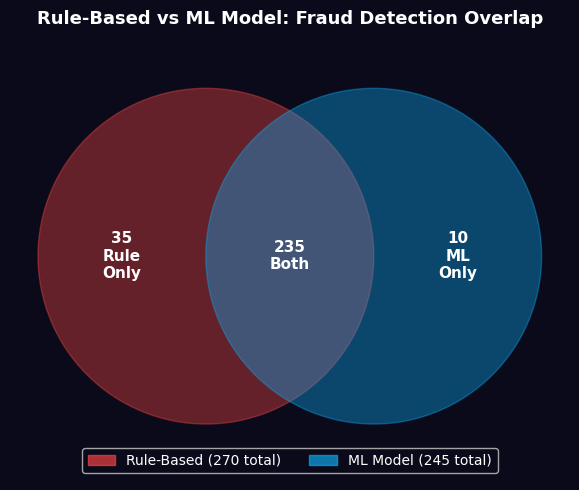

In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# CAPSTONE STEP 5 — RULE-BASED vs ML COMPARISON
#
# The key question: does the ML model find the same fraud as the rule engine,
# or does it find DIFFERENT cases?
# ─────────────────────────────────────────────────────────────────────────────

rule_flagged = set(df_output[df_output['is_fraud_flag'] == 'SUSPICIOUS'].index)
ml_flagged_set = set(df_output[df_output['ml_predicted_fraud'] == 1].index)

both_caught   = rule_flagged & ml_flagged_set
rule_only     = rule_flagged - ml_flagged_set
ml_only       = ml_flagged_set - rule_flagged

print("=" * 60)
print("  RULE-BASED vs ML MODEL COMPARISON")
print("=" * 60)
print(f"  Ground truth fraud cases      : {len(rule_flagged):,}")
print(f"  ML model flagged total        : {len(ml_flagged_set):,}")
print()
print(f"  ✅ Caught by BOTH             : {len(both_caught):,}")
print(f"  ⚠️  Rule-Based only (ML missed): {len(rule_only):,}")
print(f"  🆕 ML only (NEW patterns)     : {len(ml_only):,}")
print()
print("KEY INSIGHT:")
print(f"  The ML model flagged {len(ml_only)} transactions that the rule engine")
print(f"  did NOT flag — these are NOVEL PATTERNS the algorithm discovered")
print(f"  by learning from data, not from manually written rules.")
print()
print(f"  This demonstrates the core advantage of algorithm-based detection:")
print(f"  it can detect fraud patterns that no human analyst has explicitly")
print(f"  programmed as a rule.")

# Visualise the overlap
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#0A0A1A')
ax.set_facecolor('#0A0A1A')

# Venn diagram simulation with circles
from matplotlib.patches import Circle
circle1 = Circle((0.35, 0.5), 0.3, alpha=0.4, color=PALETTE['fraud'],   label='Rule-Based')
circle2 = Circle((0.65, 0.5), 0.3, alpha=0.4, color=PALETTE['normal'],  label='ML Model')
ax.add_patch(circle1); ax.add_patch(circle2)

ax.text(0.20, 0.50, f'{len(rule_only)}\nRule\nOnly',
        ha='center', va='center', color='white', fontsize=11, fontweight='bold')
ax.text(0.80, 0.50, f'{len(ml_only)}\nML\nOnly',
        ha='center', va='center', color='white', fontsize=11, fontweight='bold')
ax.text(0.50, 0.50, f'{len(both_caught)}\nBoth',
        ha='center', va='center', color='white', fontsize=11, fontweight='bold')

ax.set_xlim(0, 1); ax.set_ylim(0.1, 0.9)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Rule-Based vs ML Model: Fraud Detection Overlap',
             color='white', fontsize=13, fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color=PALETTE['fraud'],  alpha=0.7, label=f'Rule-Based ({len(rule_flagged)} total)'),
    mpatches.Patch(color=PALETTE['normal'], alpha=0.7, label=f'ML Model ({len(ml_flagged_set)} total)'),
], facecolor='#0A0A1A', labelcolor='white', loc='lower center', ncol=2)
plt.tight_layout()
plt.show()


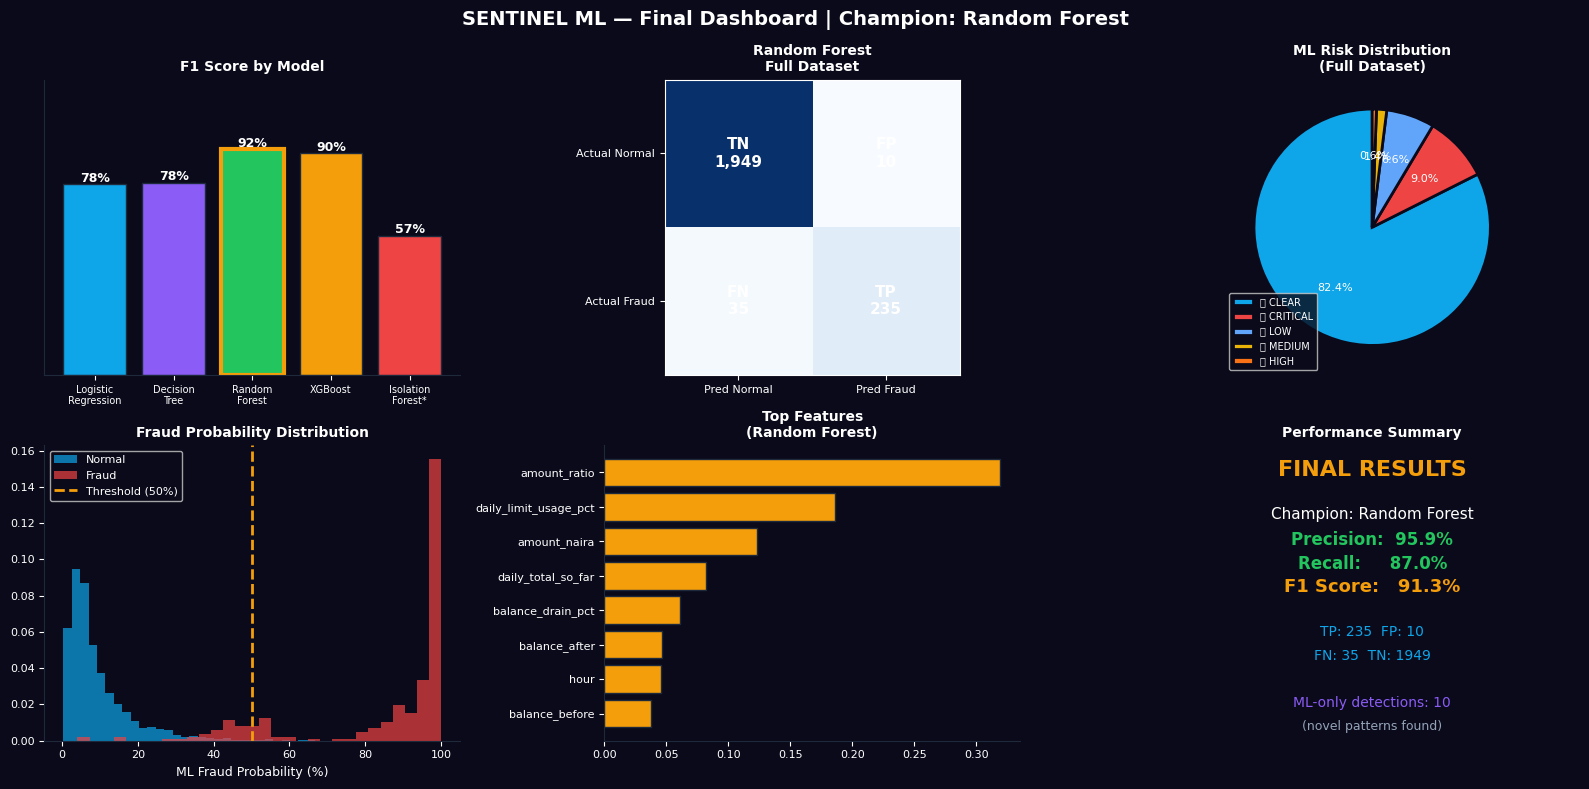


🏆 ML PIPELINE COMPLETE — PRODUCTION READY


In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# CAPSTONE STEP 6 — FINAL SUMMARY DASHBOARD
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 8))
fig.patch.set_facecolor('#0A0A1A')
fig.suptitle(f'SENTINEL ML — Final Dashboard | Champion: {champion_name}',
             color='white', fontsize=14, fontweight='bold')

# ── 1. All model F1 comparison ────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
model_scores = {
    'Logistic\nRegression': f1_lr,
    'Decision\nTree': f1_dt,
    'Random\nForest': f1_rf,
    'XGBoost': f1_xgb,
    'Isolation\nForest*': f1_iso
}
model_colors = [PALETTE['normal'], PALETTE['purple'], PALETTE['green'],
                PALETTE['gold'], PALETTE['fraud']]
bars = ax1.bar(model_scores.keys(), model_scores.values(),
               color=model_colors, edgecolor='#1E293B')
best_f1 = max(model_scores.values())
for bar, (name, val) in zip(bars, model_scores.items()):
    if val == best_f1:
        bar.set_edgecolor(PALETTE['gold']); bar.set_linewidth(3)
    ax1.text(bar.get_x()+bar.get_width()/2, val+0.01,
             f'{val*100:.0f}%', ha='center', color='white', fontsize=9, fontweight='bold')
ax1.set_title('F1 Score by Model', color='white', fontsize=10, fontweight='bold')
ax1.set_facecolor('#0A0A1A'); ax1.tick_params(colors='white', labelsize=7)
ax1.set_ylim(0, 1.2); ax1.yaxis.set_visible(False)
for s in ['top','right']: ax1.spines[s].set_visible(False)
for s in ['bottom','left']: ax1.spines[s].set_color('#1E293B')

# ── 2. Final confusion matrix ─────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
cm_final = [[tn_full, fp_full],[fn_full, tp_full]]
ax2.imshow(cm_final, cmap='Blues')
ax2.set_facecolor('#0A0A1A')
ax2.set_xticks([0,1]); ax2.set_yticks([0,1])
ax2.set_xticklabels(['Pred Normal','Pred Fraud'], color='white', fontsize=8)
ax2.set_yticklabels(['Actual Normal','Actual Fraud'], color='white', fontsize=8)
ax2.set_title(f'{champion_name}\nFull Dataset', color='white', fontsize=10, fontweight='bold')
labels_cm = [['TN','FP'],['FN','TP']]
values_cm = [[tn_full, fp_full],[fn_full, tp_full]]
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f'{labels_cm[i][j]}\n{values_cm[i][j]:,}',
                ha='center', va='center', color='white', fontsize=11, fontweight='bold')

# ── 3. Risk level distribution ────────────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
risk_counts = df_output['ml_risk_level'].value_counts()
risk_colors_map = {'🔴 CRITICAL':PALETTE['fraud'],'🟠 HIGH':'#F97316',
                   '🟡 MEDIUM':'#EAB308','🔵 LOW':'#60A5FA','🟢 CLEAR':PALETTE['normal']}
risk_colors = [risk_colors_map.get(k, PALETTE['normal']) for k in risk_counts.index]
wedges, texts, autotexts = ax3.pie(risk_counts.values, labels=None,
                                    colors=risk_colors, autopct='%1.1f%%', startangle=90,
                                    wedgeprops={'edgecolor':'#0A0A1A','linewidth':2})
for at in autotexts: at.set_color('white'); at.set_fontsize(8)
ax3.set_title('ML Risk Distribution\n(Full Dataset)', color='white', fontsize=10, fontweight='bold')
ax3.legend(risk_counts.index, facecolor='#0A0A1A', labelcolor='white',
           fontsize=7, loc='lower left')

# ── 4. Fraud probability distribution ────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
ax4.hist(df_output[df_output['is_fraud']==0]['ml_fraud_probability'],
         bins=30, color=PALETTE['normal'], alpha=0.7, label='Normal', density=True)
ax4.hist(df_output[df_output['is_fraud']==1]['ml_fraud_probability'],
         bins=30, color=PALETTE['fraud'], alpha=0.7, label='Fraud', density=True)
ax4.axvline(x=50, color=PALETTE['gold'], linestyle='--', linewidth=2, label='Threshold (50%)')
ax4.set_xlabel('ML Fraud Probability (%)', color='white', fontsize=9)
ax4.set_title('Fraud Probability Distribution', color='white', fontsize=10, fontweight='bold')
ax4.set_facecolor('#0A0A1A'); ax4.tick_params(colors='white', labelsize=8)
ax4.legend(facecolor='#0A0A1A', labelcolor='white', fontsize=8)
for s in ['top','right']: ax4.spines[s].set_visible(False)
for s in ['bottom','left']: ax4.spines[s].set_color('#1E293B')

# ── 5. Top feature importance ─────────────────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
imp_champ = pd.Series(champion_model_obj.feature_importances_, index=FEATURES).nlargest(8).sort_values()
ax5.barh(imp_champ.index, imp_champ.values, color=PALETTE['gold'], edgecolor='#1E293B')
ax5.set_title(f'Top Features\n({champion_name})', color='white', fontsize=10, fontweight='bold')
ax5.set_facecolor('#0A0A1A'); ax5.tick_params(colors='white', labelsize=8)
for s in ['top','right']: ax5.spines[s].set_visible(False)
for s in ['bottom','left']: ax5.spines[s].set_color('#1E293B')

# ── 6. Performance summary text ───────────────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
ax6.set_facecolor('#071528')
ax6.axis('off')
summary_lines = [
    ('FINAL RESULTS', 16, PALETTE['gold']),
    ('', 10, 'white'),
    (f'Champion: {champion_name}', 11, 'white'),
    (f'Precision:  {prec:.1f}%', 12, PALETTE['green']),
    (f'Recall:     {rec:.1f}%', 12, PALETTE['green']),
    (f'F1 Score:   {f1:.1f}%', 13, PALETTE['gold']),
    ('', 10, 'white'),
    (f'TP: {tp_full}  FP: {fp_full}', 10, PALETTE['normal']),
    (f'FN: {fn_full}  TN: {tn_full}', 10, PALETTE['normal']),
    ('', 10, 'white'),
    (f'ML-only detections: {len(ml_only)}', 10, PALETTE['purple']),
    ('(novel patterns found)', 9, '#94A3B8'),
]
y_pos = 0.95
for text, size, color in summary_lines:
    ax6.text(0.5, y_pos, text, ha='center', va='top', color=color,
             fontsize=size, fontweight='bold' if size>=12 else 'normal',
             transform=ax6.transAxes)
    y_pos -= 0.08

ax6.set_title('Performance Summary', color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print()
print("🏆 ML PIPELINE COMPLETE — PRODUCTION READY")


---
## 📝 Wrap-Up: Rule-Based vs Algorithm-Based — Key Takeaways

### What We Learned

| Aspect | Rule-Based (Session 3) | Algorithm-Based (This Session) |
|--------|----------------------|-------------------------------|
| **How rules are found** | Written manually by analyst | Learned automatically from data |
| **Explainability** | 100% — you wrote every rule | Partial — feature importance available |
| **Performance** | Fixed by threshold choices | Optimised by the algorithm |
| **New fraud types** | Needs manual new rule | May detect automatically |
| **Training data needed** | Zero | Requires labelled examples |
| **Industry usage** | First-pass screening layer | Second-pass refinement layer |

### In a Top-Tier Bank
Both layers run **simultaneously**:
1. **Rule engine** fires first — catches known patterns in < 1ms
2. **ML model** scores everything the rules passed — catches subtle patterns
3. **Human analyst** reviews the combined HIGH + CRITICAL queue

### Self-Study Assignments
**Task 1:** Tune the Random Forest — try `n_estimators=500` and compare the F1 score.  
**Task 2:** Try `max_depth=None` on the Decision Tree and observe overfitting (test vs train score).  
**Task 3:** Add a new feature: `txn_hour_sin = sin(2π × hour / 24)` — cyclical encoding of the hour. Does it improve performance?

---
**ZEDCREST CAPITAL | Data Analyst Training Programme | May – August 2026**  
*Trainer: Kajola Gbenga Adewale | Prodigy Training Hub*
